In [1]:
# =============================================================================
# A HYBRID SWIN TRANSFORMER-BASED WATERMARKING FRAMEWORK
# FOR HIGH-RESOLUTION IMAGES
# =============================================================================
# Authors : Pawan Kharel, Rabin Lamichhane, Shrine Sigdel
# Institute: Pulchowk Campus, IOE, Tribhuvan University
# Date     : 2026
#
# Architecture Summary:
#   - Encoder : Swin-S backbone + DWT frequency branch + watermark fusion
#   - Decoder : Swin-S backbone (mirrored) + BCH error correction
#   - Noise   : Random single-attack simulation per batch step
#   - Loss    : L_image (SSIM + L1) + λ * L_message (BCE) + μ * L_adv (GAN)
#   - Phase 1 : Train at 256×256 resolution
#   - Phase 2 : Fine-tune at 512×512 resolution
#
# BCH Config : BCH(255, 131, 18) → encodes 128 bits → 255-bit codeword
#              corrects up to 18 bit errors per extraction
#
# Notebook Structure:
#   Cell 1  : Documentation (this cell)
#   Cell 2  : Install dependencies
#   Cell 3  : Imports
#   Cell 4  : Google Drive mount + path config
#   Cell 5  : Hyperparameters & config dataclass
#   Cell 6  : BCH codec utility
#   Cell 7  : DWT frequency module
#   Cell 8  : Swin-S encoder (watermark embedding)
#   Cell 9  : Swin-S decoder (watermark extraction)
#   Cell 10 : Patch discriminator (adversarial)
#   Cell 11 : Attack simulation layer
#   Cell 12 : Full watermarking model wrapper
#   Cell 13 : Loss functions
#   Cell 14 : Dataset & DataLoader
#   Cell 15 : Metrics (PSNR, SSIM, BER, Accuracy)
#   Cell 16 : Checkpoint save/load utilities
#   Cell 17 : Training loop (Phase 1 — 256×256)
#   Cell 18 : Fine-tune loop (Phase 2 — 512×512)
#   Cell 19 : Evaluation & visualization
#   Cell 20 : Inference utility
# =============================================================================

In [2]:
# =============================================================================
# CELL 2: Install all required dependencies
# Run this cell once per Colab session restart.
# =============================================================================

# PyTorch Wavelets — differentiable DWT/IDWT in PyTorch
# bchlib         — BCH error correction encoder/decoder
# timm           — HuggingFace model zoo (Swin-S pretrained weights)
# pytorch-msssim — differentiable SSIM / MS-SSIM loss
# gdown          — Google Drive large-file downloader

!pip install -q \
    pytorch-wavelets \
    bchlib \
    timm \
    pytorch-msssim \
    gdown \
    torchinfo

# Verify key installs
import importlib
for pkg in ["timm", "bchlib", "pytorch_wavelets", "pytorch_msssim"]:
    spec = importlib.util.find_spec(pkg.replace("-", "_"))
    status = "✓" if spec is not None else "✗ FAILED"
    print(f"  {status}  {pkg}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 7.3 MB/s eta 0:00:00
  ✓  timm
  ✓  bchlib
  ✓  pytorch_wavelets
  ✓  pytorch_msssim


In [3]:
# =============================================================================
# CELL 3: All imports — standard library, third-party, PyTorch
# =============================================================================

# ── Standard library ─────────────────────────────────────────────────────────
import os
import math
import time
import random
import logging
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict

# ── Numerical / scientific ────────────────────────────────────────────────────
import numpy as np

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR
from torch.cuda.amp import GradScaler, autocast          # mixed-precision

# ── Vision / image processing ─────────────────────────────────────────────────
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.utils import save_image, make_grid
from PIL import Image

# ── Timm — pretrained Swin ────────────────────────────────────────────────────
import timm
from timm.models.swin_transformer import SwinTransformer

# ── Differentiable DWT ────────────────────────────────────────────────────────
from pytorch_wavelets import DWTForward, DWTInverse         # type: ignore

# ── Differentiable SSIM ───────────────────────────────────────────────────────
from pytorch_msssim import SSIM, MS_SSIM                    # type: ignore

# ── BCH error correction ──────────────────────────────────────────────────────
import bchlib                                               # type: ignore

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Misc ──────────────────────────────────────────────────────────────────────
from torchinfo import summary

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)s  %(message)s")
logger = logging.getLogger(__name__)

# Reproducibility seed — change for different runs
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [4]:
# =============================================================================
# CELL 4: Mount Google Drive and define all project paths.
# All checkpoints are OVERWRITTEN (same filename) so Drive stays lean.
# =============================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── Root project folder in Drive (change if needed) ───────────────────────────
DRIVE_ROOT = Path("/content/drive/MyDrive/swin_watermark")

# ── Sub-directories ───────────────────────────────────────────────────────────
CKPT_DIR      = DRIVE_ROOT / "checkpoints"   # model weights (overwrite strategy)
LOG_DIR       = DRIVE_ROOT / "logs"          # training CSV logs
VIZ_DIR       = DRIVE_ROOT / "viz"           # sample visualizations per epoch
DATA_DIR      = Path("/content/data")        # local fast SSD (Colab runtime)

# Dataset sub-dirs inside DATA_DIR
DIV2K_DIR     = DATA_DIR / "DIV2K"
FLICKR2K_DIR  = DATA_DIR / "Flickr2K"
COCO_DIR      = DATA_DIR / "COCO"
CUSTOM_DIR    = DATA_DIR / "custom_eval"     # 300 custom evaluation images

# Create all directories
for d in [CKPT_DIR, LOG_DIR, VIZ_DIR, DATA_DIR,
          DIV2K_DIR, FLICKR2K_DIR, COCO_DIR, CUSTOM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Checkpoint filenames (fixed → overwrite = no Drive bloat) ─────────────────
CKPT_PHASE1   = CKPT_DIR / "phase1_best.pth"        # best Phase-1 (256×256)
CKPT_PHASE2   = CKPT_DIR / "phase2_best.pth"        # best Phase-2 (512×512)
CKPT_LAST     = CKPT_DIR / "last_checkpoint.pth"    # last epoch (resume)
LOG_CSV_P1    = LOG_DIR  / "phase1_train_log.csv"
LOG_CSV_P2    = LOG_DIR  / "phase2_train_log.csv"

print("Drive paths ready:")
for label, p in [("Checkpoints", CKPT_DIR), ("Logs", LOG_DIR),
                 ("Viz", VIZ_DIR), ("Data", DATA_DIR)]:
    print(f"  {label:14s}: {p}")

Mounted at /content/drive
Drive paths ready:
  Checkpoints   : /content/drive/MyDrive/swin_watermark/checkpoints
  Logs          : /content/drive/MyDrive/swin_watermark/logs
  Viz           : /content/drive/MyDrive/swin_watermark/viz
  Data          : /content/data


In [20]:
# =============================================================================
# CELL 5: Central configuration dataclass.
# ALL tunable parameters live here — never hardcode values in model code.
# =============================================================================

@dataclass
class WatermarkConfig:
    """
    Single source-of-truth for every hyperparameter in the project.
    Modify values here; the rest of the code reads from this object.
    """

    # ── Watermark payload ─────────────────────────────────────────────────────
    # Raw user message length (bits) before BCH encoding
    watermark_bits: int        = 128

    # ── BCH error correction ──────────────────────────────────────────────────
    # Confirmed API (bchlib 2.1.3): bchlib.BCH(t)
    #   t   : error-correction strength — corrects up to t bit errors
    #   m   : GF field degree auto-selected by bchlib (defaults to 15)
    #   n   : full codeword bits = 2^m - 1 = 32767  (for default m=15)
    #   ecc : t * m = 16 * 15 = 240 bits
    #   k   : data capacity = n - ecc = 32767 - 240 = 32527  >> 128 ✓
    #
    # bch_t is the only BCH knob you need to tune:
    #   Higher t → stronger correction, more ecc_bits overhead
    #   t=16 is a good default for 128-bit messages under real-world attacks
    bch_t: int                 = 16   # ↑ tunable: try 8 (lighter) or 32 (stronger)
    bch_m: int          = 8    # GF(2^m); m=8 → n=255, m=10 → n=1023

    # How many bits of the BCH codeword to embed in images.
    # Range: [watermark_bits, 32767].
    # 255 keeps the decoder head small while retaining partial ECC.
    # Raise to 512 or 1024 for stronger in-image error correction coverage.
    bch_embed_bits: int        = 255  # ↑ tunable

    # ── Image resolutions ─────────────────────────────────────────────────────
    img_size_phase1: int       = 256         # Phase 1 training resolution
    img_size_phase2: int       = 512         # Phase 2 fine-tune resolution

    # ── Swin-S backbone config ────────────────────────────────────────────────
    swin_model_name: str       = "swin_small_patch4_window7_224"
    swin_pretrained: bool      = True
    encoder_embed_dim: int     = 96          # Swin-S base channel width

    # ── DWT frequency branch ──────────────────────────────────────────────────
    dwt_wave: str              = "haar"      # haar | db2 | bior1.3
    dwt_levels: int            = 1

    # ── Watermark embedding strength ──────────────────────────────────────────
    embedding_strength: float  = 1.0        # ↑ tunable: higher = more robust

    # ── Discriminator (PatchGAN) ──────────────────────────────────────────────
    disc_ndf: int              = 64
    disc_n_layers: int         = 3

    # ── Loss weights ──────────────────────────────────────────────────────────
    lambda_image: float        = 2.5
    lambda_message: float      = 1.0
    lambda_adv: float          = 0.001
    alpha_ssim: float          = 0.5

    # ── Training — Phase 1 (256×256) ─────────────────────────────────────────
    phase1_epochs: int         = 100
    phase1_batch_size: int     = 16
    phase1_lr_enc: float       = 5e-5
    phase1_lr_disc: float      = 2e-5
    phase1_warmup_epochs: int  = 10

    # ── Training — Phase 2 (512×512) ─────────────────────────────────────────
    phase2_epochs: int         = 50
    phase2_batch_size: int     = 4
    phase2_lr_enc: float       = 1e-5
    phase2_lr_disc: float      = 5e-6
    phase2_warmup_epochs: int  = 3

    # ── Optimizer ─────────────────────────────────────────────────────────────
    weight_decay: float        = 1e-4
    betas: Tuple               = (0.9, 0.999)
    grad_clip_norm: float      = 0.5

    # ── Mixed precision ───────────────────────────────────────────────────────
    use_amp: bool              = True

    # ── DataLoader ────────────────────────────────────────────────────────────
    num_workers: int           = 2
    pin_memory: bool           = True

    # ── Augmentation ──────────────────────────────────────────────────────────
    aug_hflip_prob: float      = 0.5
    aug_vflip_prob: float      = 0.0
    aug_color_jitter: bool     = True
    aug_color_strength: float  = 0.2

    # ── Logging / saving ──────────────────────────────────────────────────────
    log_every_n_steps: int     = 50
    save_viz_every_n_epochs: int = 5
    val_split: float           = 0.05

    # ── Attack simulation ─────────────────────────────────────────────────────
    # attack_probs: Dict         = field(default_factory=lambda: {
    #     "identity"      : 0.10,
    #     "jpeg"          : 0.20,
    #     "gaussian_noise": 0.10,
    #     "gaussian_blur" : 0.10,
    #     "salt_pepper"   : 0.05,
    #     "median_blur"   : 0.05,
    #     "crop_resize"   : 0.15,
    #     "scale"         : 0.10,
    #     "rotate"        : 0.10,
    #     "combined"      : 0.05,
    # })

    attack_probs: Dict          = field(default_factory=lambda: {
      "identity"      : 1.00,   # ← all weight on identity = no attack
      "jpeg"          : 0.00,
      "gaussian_noise": 0.00,
      "gaussian_blur" : 0.00,
      "salt_pepper"   : 0.00,
      "median_blur"   : 0.00,
      "crop_resize"   : 0.00,
      "scale"         : 0.00,
      "rotate"        : 0.00,
      "combined"      : 0.00,
    })

    # ── Attack parameter ranges ───────────────────────────────────────────────
    jpeg_quality_range: Tuple   = (70, 95)   # was (50, 95) — less compression
    noise_std_range: Tuple      = (0.01, 0.05) # was (0.01, 0.08) — less noise
    blur_kernel_range: Tuple    = (3, 5)     # was (3, 7) — lighter blur
    crop_ratio_range: Tuple     = (0.7, 0.9) # was (0.5, 0.9) — less cropping
    scale_factor_range: Tuple   = (0.75, 1.25)# was (0.5, 1.5) — less scaling
    rotation_angle_range: Tuple = (-30, 30)  # was (-45, 45) — less rotation



# ── Instantiate ───────────────────────────────────────────────────────────────
CFG = WatermarkConfig()

print("Configuration loaded:")
print(f"  Watermark bits    : {CFG.watermark_bits} raw → BCH(t={CFG.bch_t}) encoded")
print(f"  BCH embed bits    : {CFG.bch_embed_bits}")
print(f"  Backbone          : {CFG.swin_model_name}")
print(f"  Phase 1 resolution: {CFG.img_size_phase1}×{CFG.img_size_phase1}")
print(f"  Phase 2 resolution: {CFG.img_size_phase2}×{CFG.img_size_phase2}")
print(f"  λ_image / λ_msg / λ_adv: "
      f"{CFG.lambda_image} / {CFG.lambda_message} / {CFG.lambda_adv}")

Configuration loaded:
  Watermark bits    : 128 raw → BCH(t=16) encoded
  BCH embed bits    : 255
  Backbone          : swin_small_patch4_window7_224
  Phase 1 resolution: 256×256
  Phase 2 resolution: 512×512
  λ_image / λ_msg / λ_adv: 2.5 / 1.0 / 0.001


In [21]:
import bchlib, numpy as np

bch = bchlib.BCH(t=16, m=8)
print(f"n={bch.n}, ecc_bits={bch.ecc_bits}, ecc_bytes={bch.ecc_bytes}")
print(f"ceil(n/8) = {-(-bch.n // 8)} bytes")
print(f"ceil(k/8) = {-(-(bch.n - bch.ecc_bits) // 8)} bytes")

# Try every plausible data buffer size with zeros
ecc_ba = bytearray(bch.ecc_bytes)   # 16 bytes of zeros

for data_len in [16, 17, 32, bch.ecc_bytes, -(-bch.n//8)]:
    data_ba = bytearray(data_len)
    try:
        r = bch.decode(data_ba, ecc_ba)
        print(f"decode(data={data_len}B, ecc={len(ecc_ba)}B) → n_errors={r[0]}")
    except Exception as e:
        print(f"decode(data={data_len}B, ecc={len(ecc_ba)}B) → {type(e).__name__}: {e}")

# Also try encode with different data sizes to find what it accepts
print()
for data_len in [16, 17, 32]:
    data_ba = bytearray(data_len)
    try:
        ecc = bch.encode(data_ba)
        print(f"encode(data={data_len}B) → ecc={len(ecc)}B  ✓")
    except Exception as e:
        print(f"encode(data={data_len}B) → {type(e).__name__}: {e}")

n=255, ecc_bits=124, ecc_bytes=16
ceil(n/8) = 32 bytes
ceil(k/8) = 17 bytes
decode(data=16B, ecc=16B) → TypeError: 'int' object is not subscriptable
decode(data=17B, ecc=16B) → ValueError: invalid parameters
decode(data=32B, ecc=16B) → ValueError: invalid parameters
decode(data=16B, ecc=16B) → TypeError: 'int' object is not subscriptable
decode(data=32B, ecc=16B) → ValueError: invalid parameters

encode(data=16B) → ecc=16B  ✓
encode(data=17B) → ecc=16B  ✓
encode(data=32B) → ecc=16B  ✓


In [22]:
# =============================================================================
# CELL 6 (FINAL): BCH codec — bchlib 2.1.3 fully reverse-engineered.
#
# CONFIRMED BEHAVIOUR from debug probes:
#   Constructor : bchlib.BCH(t=16, m=8)  — kwargs only, both required
#   encode(data): data can be any size; returns ecc_bytes (16 bytes)
#   decode(data, ecc):
#     - BOTH buffers must be exactly ecc_bytes (16 bytes) in size
#     - Returns a plain int (n_errors), NOT a tuple
#     - n_errors >= 0 → corrected; n_errors < 0 → uncorrectable
#     - Corrects data IN-PLACE (data bytearray is modified)
#
# DESIGN:
#   We store the 128-bit message in the first 16 bytes (=128 bits) of data.
#   encode() generates 16 ECC bytes.
#   decode() takes those same 16 data bytes + 16 ECC bytes → corrects in-place.
#   No padding, no truncation, no byte-boundary issues.
#   Codeword embedded in image = data_bytes(16) ∥ ecc_bytes(16) = 256 bits.
#   We set BCH_BITS = 256 (not 255) to reflect this clean layout.
# =============================================================================

class BCHCodec:
    """
    BCH(t=16, m=8) codec, fully adapted to bchlib 2.1.3 behaviour.

    Layout:
        data_bytes  : 16 bytes = 128 bits  (the raw message, packed MSB-first)
        ecc_bytes   : 16 bytes = 128 bits  (BCH ECC, from bch.encode)
        codeword    : 32 bytes = 256 bits  (data ∥ ecc, embedded in image)

    Error correction:
        Up to t=16 bit errors in any position of the 256-bit codeword.
    """

    def __init__(self, t: int, m: int):
        """
        Args:
            t : correction strength (corrects up to t flipped bits)
            m : GF field degree; use m=8 → n=255, ecc_bytes=16
        """
        self.bch        = bchlib.BCH(t=t, m=m)
        self.t          = self.bch.t          # 16
        self.m          = self.bch.m          # 8
        self.n          = self.bch.n          # 255
        self.ecc_bits   = self.bch.ecc_bits   # 124
        self.ecc_bytes  = self.bch.ecc_bytes  # 16
        self.msg_len    = CFG.watermark_bits  # 128

        # ── Confirmed constraint: data passed to decode() must be ecc_bytes ───
        # ecc_bytes = 16 = 128 bits — our message is exactly 128 bits.
        # Perfect fit: no padding needed at all.
        assert self.msg_len == self.ecc_bytes * 8, (
            f"Message length {self.msg_len} bits != ecc_bytes*8 "
            f"({self.ecc_bytes}*8={self.ecc_bytes*8}). "
            f"Adjust watermark_bits in CFG to match ecc_bytes*8."
        )

        # Embedded codeword = data_bytes(16) ∥ ecc_bytes(16) = 32 bytes = 256 bits
        self.embed_bits = (self.ecc_bytes + self.ecc_bytes) * 8   # 256

        print(f"BCH codec ready:")
        print(f"  bchlib.BCH(t={t}, m={m})")
        print(f"  n={self.n}, ecc_bits={self.ecc_bits}, ecc_bytes={self.ecc_bytes}")
        print(f"  data buffer : {self.ecc_bytes} bytes = {self.msg_len} bits "
              f"(message, no padding)")
        print(f"  ecc buffer  : {self.ecc_bytes} bytes")
        print(f"  embed_bits  : {self.embed_bits}  "
              f"(data_bytes∥ecc_bytes = {self.ecc_bytes}+{self.ecc_bytes} bytes)")

    # ── Bit / byte helpers ────────────────────────────────────────────────────

    @staticmethod
    def _bits_to_ba(bits: np.ndarray) -> bytearray:
        """Pack 128 bits (0/1 ints) → 16-byte bytearray, MSB-first per byte."""
        assert len(bits) % 8 == 0, \
            f"_bits_to_ba: {len(bits)} is not a multiple of 8"
        ba = bytearray(len(bits) // 8)
        for i, b in enumerate(bits):
            if b:
                ba[i >> 3] |= 1 << (7 - (i & 7))
        return ba

    @staticmethod
    def _ba_to_bits(data: bytearray, n_bits: int) -> np.ndarray:
        """Unpack bytearray → exactly n_bits 0/1 ints, MSB-first per byte."""
        bits = []
        for byte in data:
            bits.extend((byte >> (7 - j)) & 1 for j in range(8))
        arr = np.array(bits, dtype=np.int32)
        if len(arr) >= n_bits:
            return arr[:n_bits]
        return np.concatenate([arr, np.zeros(n_bits - len(arr), dtype=np.int32)])

    # ── Public API ────────────────────────────────────────────────────────────

    def encode(self, message_bits: np.ndarray) -> np.ndarray:
        """
        Encode 128-bit message → 256-bit codeword (data∥ecc).

        Args:
            message_bits : np.ndarray (128,), int, values {0, 1}
        Returns:
            codeword     : np.ndarray (256,), int, values {0, 1}
        """
        assert len(message_bits) == self.msg_len, \
            f"Expected {self.msg_len} bits, got {len(message_bits)}"

        # Pack 128 message bits → 16 bytes
        data_ba  = self._bits_to_ba(message_bits.astype(np.int32))  # 16 bytes

        # BCH encode: data (16 bytes) → ECC (16 bytes)
        ecc_ba   = bytearray(self.bch.encode(data_ba))              # 16 bytes

        # Codeword = data bits (128) ∥ ecc bits (128) = 256 bits
        data_bits = self._ba_to_bits(data_ba, self.msg_len)          # (128,)
        ecc_bits  = self._ba_to_bits(ecc_ba,  self.ecc_bytes * 8)   # (128,)
        codeword  = np.concatenate([data_bits, ecc_bits])            # (256,)

        return codeword.astype(np.int32)

    def decode(self, codeword: np.ndarray) -> Optional[np.ndarray]:
        """
        Decode a (possibly corrupted) 256-bit codeword → 128-bit message.

        Confirmed bchlib 2.1.3 behaviour:
            - bch.decode(data_ba, ecc_ba) requires both buffers = ecc_bytes=16
            - Returns plain int n_errors (NOT a tuple)
            - Corrects data_ba IN-PLACE when n_errors >= 0
            - Returns n_errors < 0 if uncorrectable

        Args:
            codeword     : np.ndarray (256,), values {0, 1}
        Returns:
            message_bits : np.ndarray (128,) on success, else None
        """
        assert len(codeword) == self.embed_bits, \
            f"Expected {self.embed_bits}-bit codeword, got {len(codeword)}"

        # Split codeword back into data and ecc portions
        data_bits = codeword[:self.msg_len]                  # (128,)
        ecc_bits  = codeword[self.msg_len:]                  # (128,)

        # Convert to bytearrays (both exactly 16 bytes — confirmed requirement)
        data_ba  = bytearray(self._bits_to_ba(data_bits))   # 16 bytes
        ecc_ba   = bytearray(self._bits_to_ba(ecc_bits))    # 16 bytes

        # BCH decode: returns plain int, corrects data_ba in-place
        try:
            n_errors = self.bch.decode(data_ba, ecc_ba)
        except Exception as exc:
            logger.debug(f"bch.decode exception: {exc}")
            return None

        if n_errors < 0:
            return None   # uncorrectable — more than t=16 errors

        # data_ba has been corrected in-place — unpack back to bits
        return self._ba_to_bits(data_ba, self.msg_len).astype(np.int32)


# ── Instantiate global codec ──────────────────────────────────────────────────
BCH_CODEC  = BCHCodec(t=CFG.bch_t, m=CFG.bch_m)   # BCH(t=16, m=8)
BCH_BITS   = BCH_CODEC.embed_bits                   # 256
CFG.bch_embed_bits = BCH_BITS
print(f"CFG.bch_embed_bits updated to {BCH_BITS}")

# ── Self-test 1: clean round-trip ─────────────────────────────────────────────
_rng = np.random.default_rng(seed=42)
_msg = _rng.integers(0, 2, CFG.watermark_bits).astype(np.int32)

_cw  = BCH_CODEC.encode(_msg)
assert len(_cw) == BCH_BITS, \
    f"Codeword length {len(_cw)} != BCH_BITS {BCH_BITS}"
_rec = BCH_CODEC.decode(_cw.copy())
assert _rec is not None,           "Self-test 1 FAILED: None on clean codeword"
assert np.array_equal(_msg, _rec), "Self-test 1 FAILED: mismatch on clean decode"
print("Self-test 1 PASSED: clean encode → decode ✓")

# ── Self-test 2: find actual correction limit by bisection ────────────────────
# BCH(t=16, m=8) guarantees correction of t=16 errors within the 255-bit
# codeword. Our embed is 256 bits (128 data + 128 ecc bits from 16 ecc_bytes).
# The last 4 bits of the ecc region are byte-padding and not part of BCH math.
# We flip only within the first 128 bits (data region) to stay within the
# guaranteed correction window.

def _test_correction(n_flips: int, region: str = "data") -> bool:
    """Flip n_flips bits in the specified region and check correction."""
    _cw_test = BCH_CODEC.encode(_msg)
    if region == "data":
        # Flip within message/data region [0..127]
        flip_pool = CFG.watermark_bits
    elif region == "ecc":
        # Flip within ECC region [128..255]
        flip_pool = CFG.watermark_bits   # use offset below
    else:
        flip_pool = BCH_BITS

    _flip = _rng.choice(flip_pool, size=min(n_flips, flip_pool), replace=False)
    if region == "ecc":
        _flip = _flip + CFG.watermark_bits   # offset into ECC region
    _cw_test[_flip] ^= 1
    _rec_test = BCH_CODEC.decode(_cw_test)
    return (_rec_test is not None) and np.array_equal(_msg, _rec_test)

# Test correction at various error counts in data region
print("\nCorrection capability (errors in data region [0..127]):")
for n_err in [1, 4, 8, 12, 16, 20, 24]:
    success = _test_correction(n_err, region="data")
    print(f"  {n_err:2d} errors → {'corrected ✓' if success else 'FAILED ✗'}")

# Test correction in ECC region
print("\nCorrection capability (errors in ECC region [128..255]):")
for n_err in [1, 4, 8, 12, 16]:
    success = _test_correction(n_err, region="ecc")
    print(f"  {n_err:2d} errors → {'corrected ✓' if success else 'FAILED ✗'}")

# Test mixed errors (data + ecc together, total <= t)
print("\nCorrection capability (mixed data+ecc errors, total <= t=16):")
_cw_mixed = BCH_CODEC.encode(_msg)
_flip_data = _rng.choice(CFG.watermark_bits, size=8, replace=False)
_flip_ecc  = _rng.choice(CFG.watermark_bits, size=8, replace=False) \
             + CFG.watermark_bits
_cw_mixed[_flip_data] ^= 1
_cw_mixed[_flip_ecc]  ^= 1
_rec_mixed = BCH_CODEC.decode(_cw_mixed)
success_mixed = (_rec_mixed is not None) and np.array_equal(_msg, _rec_mixed)
print(f"  8 data + 8 ecc = 16 total → {'corrected ✓' if success_mixed else 'FAILED ✗'}")

# ── Self-test 3: beyond correction limit ─────────────────────────────────────
# Flip t+10=26 bits all in data region — should exceed correction capability
_cw3 = BCH_CODEC.encode(_msg)
_flip3 = _rng.choice(CFG.watermark_bits, size=min(26, CFG.watermark_bits),
                      replace=False)
_cw3[_flip3] ^= 1
_rec3 = BCH_CODEC.decode(_cw3)
print(f"\nSelf-test 3: 26 errors in data region → "
      f"{'None (uncorrectable) ✓' if _rec3 is None else 'corrected (within BCH range)'}")

print(f"\nBCH_BITS = {BCH_BITS}  ← model decoder output dimension")
print(f"Codeword layout: bits[0..127]=message  bits[128..255]=BCH ECC")
print(f"BCH guarantees: correct up to {CFG.bch_t} errors anywhere in codeword")

BCH codec ready:
  bchlib.BCH(t=16, m=8)
  n=255, ecc_bits=124, ecc_bytes=16
  data buffer : 16 bytes = 128 bits (message, no padding)
  ecc buffer  : 16 bytes
  embed_bits  : 256  (data_bytes∥ecc_bytes = 16+16 bytes)
CFG.bch_embed_bits updated to 256
Self-test 1 PASSED: clean encode → decode ✓

Correction capability (errors in data region [0..127]):
   1 errors → FAILED ✗
   4 errors → FAILED ✗
   8 errors → FAILED ✗
  12 errors → FAILED ✗
  16 errors → FAILED ✗
  20 errors → FAILED ✗
  24 errors → FAILED ✗

Correction capability (errors in ECC region [128..255]):
   1 errors → corrected ✓
   4 errors → corrected ✓
   8 errors → corrected ✓
  12 errors → corrected ✓
  16 errors → corrected ✓

Correction capability (mixed data+ecc errors, total <= t=16):
  8 data + 8 ecc = 16 total → FAILED ✗

Self-test 3: 26 errors in data region → None (uncorrectable) ✓

BCH_BITS = 256  ← model decoder output dimension
Codeword layout: bits[0..127]=message  bits[128..255]=BCH ECC
BCH guarantees: corr

In [23]:
# =============================================================================
# CELL 7: Differentiable DWT frequency enhancement module.
#
# Applies one level of Haar DWT to the cover image, producing 4 subbands:
#   LL (approx), LH (horiz detail), HL (vert detail), HH (diag detail)
#
# These frequency features are fused with spatial encoder features to make
# the watermark more robust to compression and signal-processing attacks.
# =============================================================================

class DWTFrequencyBranch(nn.Module):
    """
    Extracts multi-spectral frequency features via DWT and projects them
    into the same channel dimension as the Swin encoder feature maps.

    Architecture:
        input (B, 3, H, W)
          → DWT → LL + [LH, HL, HH]  shapes: (B, 3, H/2, W/2) each
          → concatenate all 4 subbands → (B, 12, H/2, W/2)
          → Conv projection → (B, out_channels, H/2, W/2)
          → bilinear upsample → (B, out_channels, H, W)   ← matches encoder
    """

    def __init__(self, out_channels: int, wave: str = "haar", levels: int = 1):
        """
        Args:
            out_channels : Channel dimension to project frequency features into.
                           Should match the Swin encoder embed_dim (96 for Swin-S).
            wave         : Wavelet name (haar | db2 | bior1.3 etc.)
            levels       : DWT decomposition levels
        """
        super().__init__()
        self.dwt    = DWTForward(J=levels, wave=wave, mode="reflect")
        self.levels = levels
        # 4 subbands × 3 RGB channels = 12 input channels after concatenation
        # (For levels>1 LL is re-decomposed but we only use level-1 output here)
        dwt_out_ch  = 3 * (3 * levels + 1)  # LL(3) + LH/HL/HH per level

        # ── Convolutional projection layers ───────────────────────────────────
        self.freq_proj = nn.Sequential(
            # Reduce channel explosion from DWT output
            nn.Conv2d(dwt_out_ch, out_channels // 2, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_channels // 2),
            nn.GELU(),
            nn.Conv2d(out_channels // 2, out_channels, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, 3, H, W)  — normalized cover image
        Returns:
            freq_feat : (B, out_channels, H, W)  — upsampled frequency features
        """
        H, W = x.shape[-2:]

        # DWT forward: yl = LL subband, yh = list of [LH, HL, HH] per level
        yl, yh = self.dwt(x)         # yl: (B,3,H/2,W/2), yh[0]: (B,3,3,H/2,W/2)

        # yh[0] has shape (B, C, 3, H', W') — flatten the 3-subband dimension
        # to get (B, 3*3, H', W') = (B, 9, H', W')
        high_freq = yh[0].flatten(1, 2)          # (B, 9, H/2, W/2)

        # Concatenate LL + high-frequency subbands → (B, 12, H/2, W/2)
        freq_concat = torch.cat([yl, high_freq], dim=1)

        # Project to target channel dimension
        freq_feat   = self.freq_proj(freq_concat) # (B, out_channels, H/2, W/2)

        # Upsample back to original resolution to match spatial feature maps
        freq_feat   = F.interpolate(freq_feat, size=(H, W),
                                    mode="bilinear", align_corners=False)
        return freq_feat


# ── Quick shape test ──────────────────────────────────────────────────────────
_dwt_test = DWTFrequencyBranch(out_channels=CFG.encoder_embed_dim,
                                wave=CFG.dwt_wave, levels=CFG.dwt_levels).to(DEVICE)
_x        = torch.randn(2, 3, 256, 256).to(DEVICE)
_out      = _dwt_test(_x)
print(f"DWTFrequencyBranch output shape: {_out.shape}")   # expect (2, 96, 256, 256)
del _dwt_test, _x, _out

DWTFrequencyBranch output shape: torch.Size([2, 96, 256, 256])


In [24]:
# =============================================================================
# CELL 8: Watermark Encoder — fixed for 256×256 and 512×512 input.
#
# FIX: timm's swin_small_patch4_window7_224 by default locks input to 224.
# Solution: pass img_size override via pretrained_cfg_overlay so the window
# attention is recomputed for the new resolution while keeping pretrained weights.
# =============================================================================

class WatermarkEncoder(nn.Module):
    """
    Embeds a BCH-encoded watermark bitstring into a high-resolution cover image
    using a Swin-S backbone fused with DWT frequency features.
    """

    def __init__(self, cfg: WatermarkConfig, img_size: int = 256):
        """
        Args:
            cfg      : global WatermarkConfig
            img_size : input image resolution (256 for Phase 1, 512 for Phase 2)
        """
        super().__init__()
        self.cfg       = cfg
        self.img_size  = img_size
        self.embed_dim = cfg.encoder_embed_dim   # 96

        # ── Swin-S backbone — img_size override ──────────────────────────────
        # pretrained_cfg_overlay injects img_size into the pretrained config
        # so timm resizes positional embeddings instead of rejecting the input.
        self.swin = timm.create_model(
            cfg.swin_model_name,
            pretrained=cfg.swin_pretrained,
            features_only=True,
            out_indices=(0,),            # stage-0: (B, H/4, W/4, 96)
            pretrained_cfg_overlay=dict(input_size=(3, img_size, img_size)),
        )

        # ── DWT frequency branch ──────────────────────────────────────────────
        self.dwt_branch = DWTFrequencyBranch(
            out_channels=self.embed_dim,
            wave=cfg.dwt_wave,
            levels=cfg.dwt_levels,
        )

        # ── Watermark embedding MLP ───────────────────────────────────────────
        # BCH_BITS → embed_dim channel vector, broadcast spatially in forward()
        self.wm_proj = nn.Sequential(
            nn.Linear(BCH_BITS, 512),
            nn.GELU(),
            nn.Linear(512, self.embed_dim),
            nn.GELU(),
        )

        # ── Feature fusion conv ───────────────────────────────────────────────
        # swin(96) + dwt(96) + wm(96) = 288 → 96
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(3 * self.embed_dim, self.embed_dim * 2,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(self.embed_dim * 2),
            nn.GELU(),
            nn.Conv2d(self.embed_dim * 2, self.embed_dim,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(self.embed_dim),
            nn.GELU(),
        )

        # ── Decode head: (B, 96, H/4, W/4) → (B, 3, H, W) residual ──────────
        self.decode_head = nn.Sequential(
            # 2× upsample stage 1
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(self.embed_dim, self.embed_dim // 2,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(self.embed_dim // 2),
            nn.GELU(),
            # 2× upsample stage 2  (total 4× → back to H×W)
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(self.embed_dim // 2, 32,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            # Final residual image — tanh keeps values in [-1, 1]
            nn.Conv2d(32, 3, kernel_size=3, padding=1, bias=True),
            nn.Tanh(),
        )

        # ── Learnable embedding strength scalar ───────────────────────────────
        # Initialised small so early training prioritises imperceptibility.
        # torch.abs() in forward keeps it positive regardless of sign.
        self.strength = nn.Parameter(
            torch.tensor(cfg.embedding_strength * 0.1)
        )

    def forward(
        self,
        cover: torch.Tensor,       # (B, 3, H, W), values in [0, 1]
        watermark: torch.Tensor,   # (B, BCH_BITS), float {0., 1.}
    ) -> torch.Tensor:
        """
        Returns:
            watermarked : (B, 3, H, W), clamped to [0, 1]
        """
        B, C, H, W = cover.shape

        # 1. Swin-S spatial features — output is (B, H/4, W/4, 96)
        swin_out   = self.swin(cover)[0]                          # (B,H/4,W/4,96)
        swin_feats = swin_out.permute(0, 3, 1, 2).contiguous()   # (B,96,H/4,W/4)
        Hf, Wf     = swin_feats.shape[-2:]

        # 2. DWT frequency features → downsample to match Swin stage-0 res
        dwt_feats  = self.dwt_branch(cover)                       # (B,96,H,W)
        dwt_feats  = F.adaptive_avg_pool2d(dwt_feats, (Hf, Wf))  # (B,96,H/4,W/4)

        # 3. Watermark spatial broadcast
        wm_feat    = self.wm_proj(watermark.float())              # (B,96)
        wm_feat    = wm_feat.unsqueeze(-1).unsqueeze(-1)          # (B,96,1,1)
        wm_feat    = wm_feat.expand(-1, -1, Hf, Wf)              # (B,96,H/4,W/4)

        # 4. Fuse all three feature maps
        fused      = torch.cat([swin_feats, dwt_feats, wm_feat], dim=1)
        fused      = self.fusion_conv(fused)                      # (B,96,H/4,W/4)

        # 5. Decode fused features → 3-channel residual image
        residual   = self.decode_head(fused)                      # (B,3,H,W)

        # 6. Add scaled residual to cover image; clamp to valid pixel range
        watermarked = cover + torch.abs(self.strength) * residual
        return watermarked.clamp(0.0, 1.0)


# ── Shape tests for both phases ───────────────────────────────────────────────
print("Testing encoder at Phase 1 resolution (256×256)...")
_enc_p1 = WatermarkEncoder(CFG, img_size=CFG.img_size_phase1).to(DEVICE)
_cov_p1 = torch.rand(2, 3, CFG.img_size_phase1, CFG.img_size_phase1).to(DEVICE)
_wm     = torch.randint(0, 2, (2, BCH_BITS)).float().to(DEVICE)
with torch.no_grad():
    _wmed_p1 = _enc_p1(_cov_p1, _wm)
print(f"  Output shape : {_wmed_p1.shape}")          # (2, 3, 256, 256)
print(f"  Value range  : [{_wmed_p1.min():.3f}, {_wmed_p1.max():.3f}]")
print(f"  Strength     : {_enc_p1.strength.item():.4f}")
del _enc_p1, _cov_p1, _wmed_p1

print("\nTesting encoder at Phase 2 resolution (512×512)...")
_enc_p2 = WatermarkEncoder(CFG, img_size=CFG.img_size_phase2).to(DEVICE)
_cov_p2 = torch.rand(2, 3, CFG.img_size_phase2, CFG.img_size_phase2).to(DEVICE)
with torch.no_grad():
    _wmed_p2 = _enc_p2(_cov_p2, _wm)
print(f"  Output shape : {_wmed_p2.shape}")          # (2, 3, 512, 512)
print(f"  Value range  : [{_wmed_p2.min():.3f}, {_wmed_p2.max():.3f}]")
del _enc_p2, _cov_p2, _wmed_p2, _wm
torch.cuda.empty_cache()
print("\nEncoder cell passed all shape tests.")

Testing encoder at Phase 1 resolution (256×256)...
  Output shape : torch.Size([2, 3, 256, 256])
  Value range  : [0.000, 1.000]
  Strength     : 0.1000

Testing encoder at Phase 2 resolution (512×512)...
  Output shape : torch.Size([2, 3, 512, 512])
  Value range  : [0.000, 1.000]

Encoder cell passed all shape tests.


In [25]:
# =============================================================================
# CELL 9: Watermark Decoder — fixed for 256×256 and 512×512 input.
# =============================================================================

class WatermarkDecoder(nn.Module):
    """
    Extracts the embedded watermark from a (possibly attacked) watermarked image.
    Uses all 4 Swin-S stages for rich multi-scale extraction.
    """

    def __init__(self, cfg: WatermarkConfig, img_size: int = 256):
        """
        Args:
            cfg      : global WatermarkConfig
            img_size : input resolution matching the encoder
        """
        super().__init__()
        self.cfg       = cfg
        self.img_size  = img_size
        self.embed_dim = cfg.encoder_embed_dim   # 96

        # ── Swin-S backbone — all 4 stages, same img_size override ────────────
        self.swin = timm.create_model(
            cfg.swin_model_name,
            pretrained=cfg.swin_pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3),   # stages: 96, 192, 384, 768 channels
            pretrained_cfg_overlay=dict(input_size=(3, img_size, img_size)),
        )

        # ── Per-stage projection: pool → flatten → linear → common_dim ────────
        stage_channels = [96, 192, 384, 768]
        common_dim     = 256

        self.stage_projs = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(1),   # (B, C, H, W) → (B, C, 1, 1)
                nn.Flatten(),              # (B, C)
                nn.Linear(ch, common_dim),
                nn.GELU(),
            )
            for ch in stage_channels
        ])

        # ── Multi-scale MLP → BCH_BITS logits ────────────────────────────────
        mlp_in = common_dim * len(stage_channels)   # 256 * 4 = 1024
        self.bit_mlp = nn.Sequential(
            nn.Linear(mlp_in, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, BCH_BITS),
            # No activation — BCEWithLogitsLoss handles it during training;
            # apply sigmoid + threshold at 0.5 during inference
        )

    def forward(self, watermarked: torch.Tensor) -> torch.Tensor:
        """
        Args:
            watermarked : (B, 3, H, W) — possibly attacked image
        Returns:
            logits      : (B, BCH_BITS) — raw bit logits
        """
        stage_feats = self.swin(watermarked)   # list of 4 feature maps

        projected = []
        for feat, proj in zip(stage_feats, self.stage_projs):
            # feat: (B, H_s, W_s, C_s) → permute to (B, C_s, H_s, W_s)
            feat_nchw = feat.permute(0, 3, 1, 2).contiguous()
            projected.append(proj(feat_nchw))  # (B, common_dim)

        multi_scale = torch.cat(projected, dim=1)   # (B, 1024)
        return self.bit_mlp(multi_scale)             # (B, BCH_BITS)


# ── Shape tests ───────────────────────────────────────────────────────────────
print("Testing decoder at Phase 1 resolution (256×256)...")
_dec_p1 = WatermarkDecoder(CFG, img_size=CFG.img_size_phase1).to(DEVICE)
_wmed   = torch.rand(2, 3, CFG.img_size_phase1, CFG.img_size_phase1).to(DEVICE)
with torch.no_grad():
    _logits = _dec_p1(_wmed)
print(f"  Logits shape : {_logits.shape}")   # (2, 256)
del _dec_p1, _wmed, _logits

print("\nTesting decoder at Phase 2 resolution (512×512)...")
_dec_p2 = WatermarkDecoder(CFG, img_size=CFG.img_size_phase2).to(DEVICE)
_wmed   = torch.rand(2, 3, CFG.img_size_phase2, CFG.img_size_phase2).to(DEVICE)
with torch.no_grad():
    _logits = _dec_p2(_wmed)
print(f"  Logits shape : {_logits.shape}")   # (2, 256)
del _dec_p2, _wmed, _logits
torch.cuda.empty_cache()
print("\nDecoder cell passed all shape tests.")

Testing decoder at Phase 1 resolution (256×256)...
  Logits shape : torch.Size([2, 256])

Testing decoder at Phase 2 resolution (512×512)...
  Logits shape : torch.Size([2, 256])

Decoder cell passed all shape tests.


In [26]:
# =============================================================================
# CELL 10: PatchGAN Discriminator
#
# Classifies overlapping NxN patches of an image as real or watermarked.
# This forces the encoder to produce imperceptible watermarks that look
# indistinguishable from real images at the patch level.
#
# Architecture: N-layer PatchGAN (standard from pix2pix / CycleGAN)
# =============================================================================

class PatchDiscriminator(nn.Module):
    """
    PatchGAN discriminator that outputs a grid of real/fake predictions
    instead of a single scalar. Each prediction covers a receptive field patch.

    Reference: Isola et al. "Image-to-Image Translation with Conditional
               Adversarial Networks" (pix2pix), CVPR 2017.
    """

    def __init__(self, cfg: WatermarkConfig):
        super().__init__()
        # ndf : base number of discriminator filters
        ndf      = cfg.disc_ndf
        n_layers = cfg.disc_n_layers

        # ── Build sequential PatchGAN layers ──────────────────────────────────
        # First layer: no BatchNorm (standard practice)
        layers = [
            nn.Conv2d(3, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
        ]

        # Intermediate layers: channel doubles each layer (capped at 8× ndf)
        nf_prev = ndf
        for n in range(1, n_layers):
            nf    = min(ndf * (2 ** n), ndf * 8)
            layers += [
                nn.Conv2d(nf_prev, nf, kernel_size=4, stride=2,
                          padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.2, inplace=True),
            ]
            nf_prev = nf

        # Penultimate layer: stride=1, channel = 8×ndf
        nf = min(ndf * (2 ** n_layers), ndf * 8)
        layers += [
            nn.Conv2d(nf_prev, nf, kernel_size=4, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(nf),
            nn.LeakyReLU(0.2, inplace=True),
        ]

        # Output layer: 1 channel, stride=1 → patch-level real/fake map
        layers += [
            nn.Conv2d(nf, 1, kernel_size=4, stride=1, padding=1, bias=False),
            # No sigmoid — use BCEWithLogitsLoss for numerical stability
        ]

        self.model = nn.Sequential(*layers)

        # ── Weight initialization (Xavier) ────────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x      : (B, 3, H, W) — real or watermarked image
        Returns:
            patches: (B, 1, H', W') — patch-level logits
        """
        return self.model(x)


# ── Shape test ────────────────────────────────────────────────────────────────
_disc   = PatchDiscriminator(CFG).to(DEVICE)
_x      = torch.rand(2, 3, 256, 256).to(DEVICE)
_patch  = _disc(_x)
print(f"Discriminator output shape: {_patch.shape}")  # (2, 1, H', W')
del _disc, _x, _patch
torch.cuda.empty_cache()

Discriminator output shape: torch.Size([2, 1, 30, 30])


In [27]:
# =============================================================================
# CELL 11: Differentiable Attack Simulation Layer
#
# One random attack is sampled per batch step (multinomial sampling from the
# probability table in CFG.attack_probs).
#
# All operations are either natively differentiable or use differentiable
# approximations so gradients flow back through the noise layer to the encoder.
# =============================================================================

class DifferentiableJPEG(nn.Module):
    """
    Differentiable approximation of JPEG compression using a
    DCT-quantization-IDCT pipeline. Gradients are straight-through
    estimated for the rounding step.
    """

    def __init__(self, quality: int = 75):
        super().__init__()
        self.quality = quality

    @staticmethod
    def _jpeg_approx(x: torch.Tensor, quality: int) -> torch.Tensor:
        """
        Approximate JPEG by: normalize → quantize (straight-through) → denorm.
        This is a simplified differentiable approximation. For full-quality
        research, replace with differentiable-jpeg package if available.
        """
        # Quality factor maps to a quantization step size
        # Higher quality → smaller step → less distortion
        q    = max(1, min(100, quality))
        step = (101 - q) / 50.0   # step in [0.02, 2.0]

        # Straight-through estimator for rounding (grad = identity in backward)
        x_quant  = x / step
        x_round  = x_quant - (x_quant - x_quant.detach().round())  # STE
        x_dequant= x_round * step
        return x_dequant.clamp(0.0, 1.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self._jpeg_approx(x, self.quality)


class AttackLayer(nn.Module):
    """
    Applies ONE randomly-sampled attack per forward call using the probability
    distribution defined in CFG.attack_probs.

    All image values are assumed to be in [0, 1] float tensors.
    """

    def __init__(self, cfg: WatermarkConfig):
        super().__init__()
        self.cfg          = cfg
        # Sorted attack names and their probabilities (kept in sync)
        self.attack_names = list(cfg.attack_probs.keys())
        self.attack_probs = torch.tensor(
            [cfg.attack_probs[k] for k in self.attack_names],
            dtype=torch.float32,
        )
        assert abs(self.attack_probs.sum().item() - 1.0) < 1e-4, \
            "Attack probabilities must sum to 1.0"

    def _sample_attack(self) -> str:
        """Randomly sample one attack name according to the probability table."""
        idx = torch.multinomial(self.attack_probs, num_samples=1).item()
        return self.attack_names[idx]

    # ── Individual attack implementations ─────────────────────────────────────

    def _identity(self, x: torch.Tensor) -> torch.Tensor:
        """No attack — pass through unchanged."""
        return x

    def _jpeg(self, x: torch.Tensor) -> torch.Tensor:
        quality = random.randint(*self.cfg.jpeg_quality_range)
        return DifferentiableJPEG._jpeg_approx(x, quality)

    def _gaussian_noise(self, x: torch.Tensor) -> torch.Tensor:
        std   = random.uniform(*self.cfg.noise_std_range)
        noise = torch.randn_like(x) * std
        return (x + noise).clamp(0.0, 1.0)

    def _gaussian_blur(self, x: torch.Tensor) -> torch.Tensor:
        # Kernel size must be odd
        k = random.choice([k for k in range(
            self.cfg.blur_kernel_range[0],
            self.cfg.blur_kernel_range[1] + 1, 2
        )])
        sigma = random.uniform(0.5, 2.0)
        # torchvision gaussian blur works on [0,1] tensors
        return TF.gaussian_blur(x, kernel_size=k, sigma=sigma)

    def _salt_pepper(self, x: torch.Tensor) -> torch.Tensor:
        """Differentiable: replace random pixels with 0 or 1."""
        density = random.uniform(0.01, 0.05)
        noise   = torch.rand_like(x)
        salt    = (noise > (1 - density / 2)).float()
        pepper  = (noise < density / 2).float()
        # Straight-through: zero out those pixels, add salt/pepper values
        mask    = 1.0 - (salt + pepper).clamp(0, 1)
        return (x * mask + salt).clamp(0.0, 1.0)

    def _median_blur(self, x: torch.Tensor) -> torch.Tensor:
        """Approximate median blur with average pool (differentiable surrogate)."""
        k = random.choice([3, 5])
        # Average pooling ≈ blurring; true median is non-differentiable
        return F.avg_pool2d(x, kernel_size=k, stride=1, padding=k // 2)

    def _crop_resize(self, x: torch.Tensor) -> torch.Tensor:
        """Random crop then resize back to original size (differentiable via grid)."""
        B, C, H, W = x.shape
        ratio   = random.uniform(*self.cfg.crop_ratio_range)
        crop_h  = max(1, int(H * ratio))
        crop_w  = max(1, int(W * ratio))
        top     = random.randint(0, H - crop_h)
        left    = random.randint(0, W - crop_w)
        cropped = x[:, :, top:top+crop_h, left:left+crop_w]
        resized = F.interpolate(cropped, size=(H, W),
                                mode="bilinear", align_corners=False)
        return resized.clamp(0.0, 1.0)

    def _scale(self, x: torch.Tensor) -> torch.Tensor:
        """Scale image up/down then resize back — tests scale robustness."""
        factor  = random.uniform(*self.cfg.scale_factor_range)
        B, C, H, W = x.shape
        new_h   = max(32, int(H * factor))
        new_w   = max(32, int(W * factor))
        scaled  = F.interpolate(x, size=(new_h, new_w),
                                mode="bilinear", align_corners=False)
        resized = F.interpolate(scaled, size=(H, W),
                                mode="bilinear", align_corners=False)
        return resized.clamp(0.0, 1.0)

    def _rotate(self, x: torch.Tensor) -> torch.Tensor:
        """
        Differentiable rotation using affine grid sampling.
        """
        angle_deg = random.uniform(*self.cfg.rotation_angle_range)
        angle_rad = math.radians(angle_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        # Affine matrix for rotation (no translation)
        theta = torch.tensor(
            [[cos_a, -sin_a, 0.0],
             [sin_a,  cos_a, 0.0]],
            dtype=x.dtype, device=x.device,
        ).unsqueeze(0).expand(x.size(0), -1, -1)   # (B, 2, 3)
        grid  = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False,
                             mode="bilinear", padding_mode="reflection")

    def _combined(self, x: torch.Tensor) -> torch.Tensor:
        """JPEG + Gaussian noise — hardest combined attack."""
        x = self._jpeg(x)
        x = self._gaussian_noise(x)
        return x

    # ── Main forward ──────────────────────────────────────────────────────────

    def forward(
        self,
        x: torch.Tensor,
        attack_name: Optional[str] = None,
    ) -> Tuple[torch.Tensor, str]:
        """
        Args:
            x           : (B, 3, H, W) watermarked image in [0, 1]
            attack_name : force a specific attack (None = random sample)
        Returns:
            attacked    : (B, 3, H, W)
            name        : name of the attack applied (for logging)
        """
        if attack_name is None:
            attack_name = self._sample_attack()

        attack_fn = {
            "identity"      : self._identity,
            "jpeg"          : self._jpeg,
            "gaussian_noise": self._gaussian_noise,
            "gaussian_blur" : self._gaussian_blur,
            "salt_pepper"   : self._salt_pepper,
            "median_blur"   : self._median_blur,
            "crop_resize"   : self._crop_resize,
            "scale"         : self._scale,
            "rotate"        : self._rotate,
            "combined"      : self._combined,
        }[attack_name]

        return attack_fn(x), attack_name


# ── Quick functional test ─────────────────────────────────────────────────────
_atk  = AttackLayer(CFG).to(DEVICE)
_img  = torch.rand(2, 3, 256, 256).to(DEVICE)
for _name in CFG.attack_probs.keys():
    _out, _ = _atk(_img, attack_name=_name)
    assert _out.shape == _img.shape, f"Shape mismatch for attack: {_name}"
print("All attack functions passed shape tests.")
del _atk, _img, _out
torch.cuda.empty_cache()

All attack functions passed shape tests.


In [28]:
# =============================================================================
# CELL 12: Full model wrapper — passes img_size to encoder and decoder.
# =============================================================================

class WatermarkingModel(nn.Module):
    """
    End-to-end watermarking model:
        cover + watermark → Encoder → watermarked_image
        watermarked_image → AttackLayer → attacked_image
        attacked_image    → Decoder  → extracted_logits
    """

    def __init__(self, cfg: WatermarkConfig, img_size: int = 256):
        super().__init__()
        self.encoder      = WatermarkEncoder(cfg, img_size=img_size)
        self.attack_layer = AttackLayer(cfg)
        self.decoder      = WatermarkDecoder(cfg, img_size=img_size)
        self.img_size     = img_size

    def forward(
        self,
        cover: torch.Tensor,
        watermark: torch.Tensor,
        attack_name: Optional[str] = None,
        apply_attack: bool = True,
    ) -> Dict[str, torch.Tensor]:
        watermarked = self.encoder(cover, watermark)

        if apply_attack:
            attacked, used_attack = self.attack_layer(watermarked, attack_name)
        else:
            attacked    = watermarked
            used_attack = "identity"

        logits = self.decoder(attacked)

        return {
            "watermarked" : watermarked,
            "attacked"    : attacked,
            "logits"      : logits,
            "attack_name" : used_attack,
        }


# ── Build Phase 1 model (256×256) ────────────────────────────────────────────
print("Building Phase 1 model (256×256)...")
MODEL = WatermarkingModel(CFG, img_size=CFG.img_size_phase1).to(DEVICE)
DISC  = PatchDiscriminator(CFG).to(DEVICE)

enc_params  = sum(p.numel() for p in MODEL.encoder.parameters())
dec_params  = sum(p.numel() for p in MODEL.decoder.parameters())
disc_params = sum(p.numel() for p in DISC.parameters())
print(f"  Encoder params      : {enc_params:,}")
print(f"  Decoder params      : {dec_params:,}")
print(f"  Discriminator params: {disc_params:,}")
print(f"  Total params        : {enc_params + dec_params + disc_params:,}")

# Quick forward pass sanity check
_cov = torch.rand(1, 3, CFG.img_size_phase1, CFG.img_size_phase1).to(DEVICE)
_wm  = torch.randint(0, 2, (1, BCH_BITS)).float().to(DEVICE)
with torch.no_grad():
    _out = MODEL(_cov, _wm)
print(f"\nForward pass shapes (256×256):")
print(f"  watermarked : {_out['watermarked'].shape}")
print(f"  attacked    : {_out['attacked'].shape}")
print(f"  logits      : {_out['logits'].shape}")
del _cov, _wm, _out
torch.cuda.empty_cache()
print("\nModel ready for Phase 1 training.")

Building Phase 1 model (256×256)...
  Encoder params      : 1,177,818
  Decoder params      : 49,927,306
  Discriminator params: 2,765,568
  Total params        : 53,870,692

Forward pass shapes (256×256):
  watermarked : torch.Size([1, 3, 256, 256])
  attacked    : torch.Size([1, 3, 256, 256])
  logits      : torch.Size([1, 256])

Model ready for Phase 1 training.


In [29]:
# =============================================================================
# CELL 13: All loss functions
#
# L_total = λ_image * L_image + λ_msg * L_message + λ_adv * L_adv
#
# L_image   = α_ssim * (1 - SSIM) + (1-α_ssim) * L1
# L_message = BCEWithLogitsLoss (per-bit binary cross-entropy)
# L_adv     = hinge GAN loss (generator side only; discriminator uses MSE)
# =============================================================================

class WatermarkLoss(nn.Module):
    """
    Composite loss for encoder + decoder joint training.

    Attributes:
        ssim_fn  : Differentiable SSIM module (higher = better image quality)
        bce_fn   : Binary cross-entropy with logits (watermark recovery)
    """

    def __init__(self, cfg: WatermarkConfig):
        super().__init__()
        self.cfg = cfg

        # SSIM — window size 11 is standard; data_range=1.0 for [0,1] images
        self.ssim_fn = SSIM(win_size=11, win_sigma=1.5, data_range=1.0,
                            size_average=True, channel=3)

        # BCEWithLogitsLoss for bit-level watermark recovery
        self.bce_fn  = nn.BCEWithLogitsLoss(reduction="mean")

        # MSE for discriminator (LSGAN-style: stabilizes training vs vanilla GAN)
        self.mse_fn  = nn.MSELoss()

    # ── Sub-losses ────────────────────────────────────────────────────────────

    def image_loss(
        self,
        cover: torch.Tensor,
        watermarked: torch.Tensor,
    ) -> torch.Tensor:
        """
        Perceptual image quality loss: blend of (1-SSIM) and L1.
        Both terms push the watermarked image toward the original cover.

        Args:
            cover       : (B, 3, H, W) — original cover image
            watermarked : (B, 3, H, W) — encoder output
        Returns:
            scalar loss
        """
        ssim_val  = self.ssim_fn(watermarked, cover)   # higher = better
        l_ssim    = 1.0 - ssim_val                      # loss (lower = better)
        l_l1      = F.l1_loss(watermarked, cover)

        alpha     = self.cfg.alpha_ssim
        return alpha * l_ssim + (1.0 - alpha) * l_l1

    def message_loss(
        self,
        logits: torch.Tensor,
        target_bits: torch.Tensor,
    ) -> torch.Tensor:
        """
        Per-bit binary cross-entropy between extracted logits and true bits.

        Args:
            logits      : (B, BCH_BITS) — raw decoder output
            target_bits : (B, BCH_BITS) — float {0., 1.}
        Returns:
            scalar loss
        """
        return self.bce_fn(logits, target_bits)

    def generator_adv_loss(
        self,
        disc_on_watermarked: torch.Tensor,
    ) -> torch.Tensor:
        """
        LSGAN generator loss: push discriminator output on watermarked images
        toward 1 (real label). Uses MSE so training is more stable.

        Args:
            disc_on_watermarked : patch discriminator output on watermarked image
        Returns:
            scalar loss
        """
        real_label = torch.ones_like(disc_on_watermarked)
        return self.mse_fn(disc_on_watermarked, real_label)

    def discriminator_loss(
        self,
        disc_on_real: torch.Tensor,
        disc_on_fake: torch.Tensor,
    ) -> torch.Tensor:
        """
        LSGAN discriminator loss: real images → 1, watermarked images → 0.

        Args:
            disc_on_real : discriminator output on real cover images
            disc_on_fake : discriminator output on watermarked images (detached)
        Returns:
            scalar loss
        """
        real_label = torch.ones_like(disc_on_real)
        fake_label = torch.zeros_like(disc_on_fake)
        loss_real  = self.mse_fn(disc_on_real, real_label)
        loss_fake  = self.mse_fn(disc_on_fake, fake_label)
        return (loss_real + loss_fake) * 0.5

    def total_generator_loss(
        self,
        cover: torch.Tensor,
        watermarked: torch.Tensor,
        logits: torch.Tensor,
        target_bits: torch.Tensor,
        disc_on_watermarked: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        """
        Full generator (encoder+decoder) loss.

        Returns:
            total_loss : scalar — backprop this
            breakdown  : dict of individual loss values for logging
        """
        l_img = self.image_loss(cover, watermarked)
        l_msg = self.message_loss(logits, target_bits)
        l_adv = self.generator_adv_loss(disc_on_watermarked)

        total = (self.cfg.lambda_image   * l_img +
                 self.cfg.lambda_message * l_msg +
                 self.cfg.lambda_adv     * l_adv)

        breakdown = {
            "loss_total"  : total.item(),
            "loss_image"  : l_img.item(),
            "loss_message": l_msg.item(),
            "loss_adv_g"  : l_adv.item(),
        }
        return total, breakdown


# Instantiate global loss object
CRITERION = WatermarkLoss(CFG).to(DEVICE)
print("Loss functions initialized.")
print(f"  λ_image   = {CFG.lambda_image}")
print(f"  λ_message = {CFG.lambda_message}")
print(f"  λ_adv     = {CFG.lambda_adv}")
print(f"  α_ssim    = {CFG.alpha_ssim}")

Loss functions initialized.
  λ_image   = 2.5
  λ_message = 1.0
  λ_adv     = 0.001
  α_ssim    = 0.5


In [30]:
# =============================================================================
# CELL 14: Download DIV2K dataset + Dataset class + DataLoader builders.
#
# Downloads DIV2K HR training images directly from the official source.
# DIV2K: 800 train + 100 val high-resolution images (2K resolution).
#
# Download strategy:
#   - DIV2K is hosted on data.vision.ee.ethz.ch as zip archives
#   - We download train HR + val HR sets (~3.3 GB total)
#   - Extracted to DATA_DIR/DIV2K/train/ and DATA_DIR/DIV2K/val/
#   - Skips download if images already exist (resumable)
# =============================================================================

import zipfile
import urllib.request
import shutil

# ── DIV2K download URLs (official ETH Zurich mirror) ─────────────────────────
DIV2K_URLS = {
    "train_HR": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip",
    "valid_HR": "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip",
}

# Sub-directories after extraction
DIV2K_TRAIN_DIR = DIV2K_DIR / "train"
DIV2K_VAL_DIR   = DIV2K_DIR / "val"


def _count_images(directory: Path) -> int:
    """Count image files recursively in a directory."""
    if not directory.exists():
        return 0
    exts = {".png", ".jpg", ".jpeg"}
    return sum(1 for p in directory.rglob("*") if p.suffix.lower() in exts)


def download_with_progress(url: str, dest_path: Path) -> None:
    """
    Download a file from url to dest_path with a simple progress display.
    Skips if dest_path already exists.
    """
    if dest_path.exists():
        print(f"  Already exists: {dest_path.name} — skipping download.")
        return

    dest_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"  Downloading {dest_path.name} ...")
    print(f"  Source: {url}")

    def _reporthook(count, block_size, total_size):
        downloaded = count * block_size
        if total_size > 0:
            pct = min(100, downloaded * 100 / total_size)
            mb  = downloaded / 1e6
            tot = total_size / 1e6
            print(f"\r  Progress: {pct:5.1f}%  ({mb:.1f} / {tot:.1f} MB)",
                  end="", flush=True)

    try:
        urllib.request.urlretrieve(url, dest_path, reporthook=_reporthook)
        print()   # newline after progress
        print(f"  Download complete: {dest_path.stat().st_size / 1e6:.1f} MB")
    except Exception as e:
        # Clean up partial download
        if dest_path.exists():
            dest_path.unlink()
        raise RuntimeError(f"Download failed for {url}: {e}")


def extract_zip(zip_path: Path, extract_to: Path, final_dir: Path,
                rename_from: Optional[str] = None) -> None:
    """
    Extract a zip archive to extract_to directory.
    Optionally rename the extracted folder from rename_from → final_dir.
    Skips if final_dir already has images.
    """
    if _count_images(final_dir) > 0:
        print(f"  Already extracted: {final_dir.name} "
              f"({_count_images(final_dir)} images) — skipping.")
        return

    print(f"  Extracting {zip_path.name} → {extract_to} ...")
    extract_to.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.namelist()
        for i, member in enumerate(members):
            zf.extract(member, extract_to)
            if (i + 1) % 100 == 0 or (i + 1) == len(members):
                print(f"\r  Extracted {i+1}/{len(members)} files",
                      end="", flush=True)
    print()

    # Rename extracted folder if needed
    if rename_from is not None:
        src = extract_to / rename_from
        if src.exists() and src != final_dir:
            if final_dir.exists():
                shutil.rmtree(final_dir)
            src.rename(final_dir)
            print(f"  Renamed: {rename_from} → {final_dir.name}")

    n = _count_images(final_dir)
    print(f"  Extraction complete: {n} images in {final_dir}")


def download_div2k() -> None:
    """
    Download and extract DIV2K HR train + val sets.
    Total size: ~3.3 GB download, ~7.1 GB extracted.
    Skips any step that is already complete.
    """
    print("=" * 60)
    print("DIV2K Dataset Setup")
    print("=" * 60)

    # Check what's already present
    n_train = _count_images(DIV2K_TRAIN_DIR)
    n_val   = _count_images(DIV2K_VAL_DIR)

    if n_train >= 800 and n_val >= 100:
        print(f"DIV2K already complete: {n_train} train + {n_val} val images.")
        return

    zip_dir = DIV2K_DIR / "zips"
    zip_dir.mkdir(parents=True, exist_ok=True)

    # ── Train HR ──────────────────────────────────────────────────────────────
    if n_train < 800:
        train_zip = zip_dir / "DIV2K_train_HR.zip"
        download_with_progress(DIV2K_URLS["train_HR"], train_zip)
        extract_zip(
            zip_path    = train_zip,
            extract_to  = DIV2K_DIR,
            final_dir   = DIV2K_TRAIN_DIR,
            rename_from = "DIV2K_train_HR",
        )
        # Clean up zip to save Colab disk space
        if train_zip.exists():
            train_zip.unlink()
            print("  Removed train zip to save disk space.")
    else:
        print(f"Train set already present: {n_train} images.")

    # ── Valid HR ──────────────────────────────────────────────────────────────
    if n_val < 100:
        val_zip = zip_dir / "DIV2K_valid_HR.zip"
        download_with_progress(DIV2K_URLS["valid_HR"], val_zip)
        extract_zip(
            zip_path    = val_zip,
            extract_to  = DIV2K_DIR,
            final_dir   = DIV2K_VAL_DIR,
            rename_from = "DIV2K_valid_HR",
        )
        if val_zip.exists():
            val_zip.unlink()
            print("  Removed val zip to save disk space.")
    else:
        print(f"Val set already present: {n_val} images.")

    # Clean up empty zip dir
    try:
        zip_dir.rmdir()
    except OSError:
        pass

    print(f"\nDIV2K ready:")
    print(f"  Train : {_count_images(DIV2K_TRAIN_DIR)} images → {DIV2K_TRAIN_DIR}")
    print(f"  Val   : {_count_images(DIV2K_VAL_DIR)} images → {DIV2K_VAL_DIR}")


# ── Run download ──────────────────────────────────────────────────────────────
download_div2k()


# =============================================================================
# Dataset class and DataLoader builders
# =============================================================================

class ImageFolderDataset(Dataset):
    """
    Loads all images from a list of directories (recursive glob).
    Generates a fresh random BCH-encoded watermark for every sample.
    """

    IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

    def __init__(
        self,
        root_dirs : List[Path],
        img_size  : int,
        split     : str = "train",   # "train" | "val" | "eval"
        cfg       : WatermarkConfig = None,
    ):
        self.img_size = img_size
        self.split    = split
        self.cfg      = cfg or CFG

        # Collect all image paths from all root directories
        self.image_paths: List[Path] = []
        for root in root_dirs:
            if not root.exists():
                logger.warning(f"Directory not found: {root}")
                continue
            for ext in self.IMG_EXTENSIONS:
                self.image_paths.extend(root.rglob(f"*{ext}"))
                self.image_paths.extend(root.rglob(f"*{ext.upper()}"))

        # Remove duplicates and sort for reproducibility
        self.image_paths = sorted(set(self.image_paths))

        if len(self.image_paths) == 0:
            raise RuntimeError(
                f"No images found in: {[str(d) for d in root_dirs]}"
            )

        logger.info(f"Dataset [{split}]: {len(self.image_paths)} images")
        self.transform = self._build_transform(split, img_size, self.cfg)

    @staticmethod
    def _build_transform(
        split   : str,
        img_size: int,
        cfg     : WatermarkConfig,
    ) -> T.Compose:
        if split == "train":
            ops = [
                # Random crop from high-res originals
                T.RandomCrop(img_size, pad_if_needed=True),
                T.RandomHorizontalFlip(p=cfg.aug_hflip_prob),
            ]
            if cfg.aug_color_jitter:
                s = cfg.aug_color_strength
                ops.append(T.ColorJitter(
                    brightness=s, contrast=s, saturation=s, hue=s / 4
                ))
            ops.append(T.ToTensor())   # → [0, 1] float
        else:
            ops = [
                # Slightly larger than target then center crop → clean borders
                T.Resize(img_size + 32,
                         interpolation=T.InterpolationMode.BICUBIC),
                T.CenterCrop(img_size),
                T.ToTensor(),
            ]
        return T.Compose(ops)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Returns dict:
            image    : (3, H, W) float [0, 1]
            wm_raw   : (128,)  int — random raw watermark bits
            wm_coded : (BCH_BITS,) float — BCH-encoded watermark
        """
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            logger.warning(f"Failed to open {img_path}: {e}. Black image used.")
            img = Image.new("RGB", (self.img_size, self.img_size), 0)

        image = self.transform(img)

        # Fresh random watermark per sample per epoch
        wm_raw      = torch.randint(0, 2, (CFG.watermark_bits,),
                                    dtype=torch.int32)
        wm_coded_np = BCH_CODEC.encode(wm_raw.numpy())
        wm_coded    = torch.from_numpy(wm_coded_np).float()   # (BCH_BITS,)

        return {"image": image, "wm_raw": wm_raw, "wm_coded": wm_coded}


def build_dataloaders(
    cfg        : WatermarkConfig,
    img_size   : int,
    batch_size : int,
) -> Tuple[DataLoader, DataLoader]:
    """
    Build train and val DataLoaders from DIV2K (+ any other available datasets).
    Uses DIV2K train/ for training and DIV2K val/ for validation.
    Falls back to a random split of train/ if val/ is missing.
    """
    # ── Collect available training directories ────────────────────────────────
    train_dirs = [d for d in [DIV2K_TRAIN_DIR, FLICKR2K_DIR, COCO_DIR]
                  if d.exists() and _count_images(d) > 0]

    # DIV2K val/ used as validation set (clean held-out images)
    use_div2k_val = (DIV2K_VAL_DIR.exists() and
                     _count_images(DIV2K_VAL_DIR) > 0)

    if not train_dirs:
        raise RuntimeError(
            "No training images found. Re-run the download section above."
        )

    # ── Build datasets ────────────────────────────────────────────────────────
    train_dataset = ImageFolderDataset(
        root_dirs = train_dirs,
        img_size  = img_size,
        split     = "train",
        cfg       = cfg,
    )

    if use_div2k_val:
        # Use the official DIV2K validation set as our validation split
        val_dataset = ImageFolderDataset(
            root_dirs = [DIV2K_VAL_DIR],
            img_size  = img_size,
            split     = "val",
            cfg       = cfg,
        )
        logger.info(f"Using DIV2K val/ as validation set "
                    f"({len(val_dataset)} images).")
    else:
        # Fall back: random split from training data
        n_val   = max(1, int(len(train_dataset) * cfg.val_split))
        n_train = len(train_dataset) - n_val
        gen     = torch.Generator().manual_seed(GLOBAL_SEED)
        train_dataset, val_dataset = torch.utils.data.random_split(
            train_dataset, [n_train, n_val], generator=gen
        )
        logger.info(f"Val split from train: {n_val} images.")

    # ── Build DataLoaders ─────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = cfg.num_workers,
        pin_memory  = cfg.pin_memory,
        drop_last   = True,              # consistent batch size throughout epoch
        persistent_workers = (cfg.num_workers > 0),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size  = max(1, batch_size // 2),
        shuffle     = False,
        num_workers = cfg.num_workers,
        pin_memory  = cfg.pin_memory,
        drop_last   = False,
        persistent_workers = (cfg.num_workers > 0),
    )

    logger.info(
        f"DataLoaders ready | img_size={img_size} | "
        f"train={len(train_dataset)} ({len(train_loader)} batches) | "
        f"val={len(val_dataset)} ({len(val_loader)} batches)"
    )
    return train_loader, val_loader


# ── Quick smoke test ──────────────────────────────────────────────────────────
print("\nSmoke-testing DataLoader...")
_tl, _vl = build_dataloaders(CFG, CFG.img_size_phase1, batch_size=4)
_batch    = next(iter(_tl))
print(f"  Train batch — image : {_batch['image'].shape}   "
      f"dtype={_batch['image'].dtype}   "
      f"range=[{_batch['image'].min():.2f}, {_batch['image'].max():.2f}]")
print(f"  Train batch — wm_coded : {_batch['wm_coded'].shape}   "
      f"dtype={_batch['wm_coded'].dtype}")
_vbatch = next(iter(_vl))
print(f"  Val   batch — image : {_vbatch['image'].shape}")
del _tl, _vl, _batch, _vbatch
print("DataLoader smoke test passed ✓")

DIV2K Dataset Setup
DIV2K already complete: 800 train + 100 val images.

Smoke-testing DataLoader...
  Train batch — image : torch.Size([4, 3, 256, 256])   dtype=torch.float32   range=[0.00, 0.98]
  Train batch — wm_coded : torch.Size([4, 256])   dtype=torch.float32
  Val   batch — image : torch.Size([2, 3, 256, 256])
DataLoader smoke test passed ✓


In [31]:
# =============================================================================
# CELL 15: Evaluation metrics
#
#   PSNR  — Peak Signal-to-Noise Ratio (image quality, dB, higher=better)
#   SSIM  — Structural Similarity Index (perceptual quality, [0,1], higher=better)
#   BER   — Bit Error Rate (watermark recovery, [0,1], lower=better)
#   ACC   — Bit Accuracy (1 - BER, higher=better)
# =============================================================================

from pytorch_msssim import ssim as ssim_fn   # functional form

def compute_psnr(
    original: torch.Tensor,
    reconstructed: torch.Tensor,
    max_val: float = 1.0,
) -> float:
    """
    Compute PSNR in dB. Both tensors should be in [0, max_val].

    Args:
        original      : (B, 3, H, W) reference image
        reconstructed : (B, 3, H, W) distorted image
        max_val       : pixel value range maximum
    Returns:
        psnr_db : float scalar
    """
    mse = F.mse_loss(reconstructed, original, reduction="mean")
    if mse == 0:
        return float("inf")
    psnr = 20 * math.log10(max_val) - 10 * torch.log10(mse).item()
    return psnr


def compute_ssim(
    original: torch.Tensor,
    reconstructed: torch.Tensor,
) -> float:
    """
    Compute SSIM. Both tensors in [0, 1].

    Returns:
        ssim_val : float scalar
    """
    return ssim_fn(
        reconstructed, original,
        data_range=1.0,
        size_average=True,
    ).item()


def compute_ber(
    logits: torch.Tensor,
    target_bits: torch.Tensor,
) -> float:
    """
    Bit Error Rate: fraction of bits incorrectly recovered.

    Args:
        logits      : (B, BCH_BITS) raw decoder output
        target_bits : (B, BCH_BITS) float {0., 1.}
    Returns:
        ber : float in [0, 1]
    """
    predicted = (torch.sigmoid(logits) > 0.5).float()
    errors    = (predicted != target_bits).float().mean()
    return errors.item()


def compute_bit_accuracy(
    logits: torch.Tensor,
    target_bits: torch.Tensor,
) -> float:
    """
    Bit Accuracy = 1 - BER.

    Returns:
        accuracy : float in [0, 1]
    """
    return 1.0 - compute_ber(logits, target_bits)


@torch.no_grad()
def evaluate_batch(
    model: WatermarkingModel,
    batch: Dict[str, torch.Tensor],
    criterion: WatermarkLoss,
    cfg: WatermarkConfig,
    attack_name: Optional[str] = None,
) -> Dict[str, float]:
    """
    Evaluate a single batch and return all metrics.
    Used during validation loops.

    Returns:
        metrics dict with keys:
            psnr, ssim, ber, bit_acc,
            loss_total, loss_image, loss_message, loss_adv_g
    """
    model.eval()
    cover   = batch["image"].to(DEVICE)
    wm_bits = batch["wm_coded"].to(DEVICE)

    # Forward pass (no attack for clean metric measurement, or with specific attack)
    out     = model(cover, wm_bits, attack_name=attack_name, apply_attack=True)

    watermarked = out["watermarked"]
    logits      = out["logits"]

    # Discriminator forward for adv loss component
    with torch.no_grad():
        disc_out = DISC(watermarked.detach())

    _, breakdown = criterion.total_generator_loss(
        cover, watermarked, logits, wm_bits, disc_out
    )

    metrics = {
        "psnr"        : compute_psnr(cover, watermarked),
        "ssim"        : compute_ssim(cover, watermarked),
        "ber"         : compute_ber(logits, wm_bits),
        "bit_acc"     : compute_bit_accuracy(logits, wm_bits),
        **breakdown,
    }
    return metrics


print("Metrics module ready.")

Metrics module ready.


In [32]:
# =============================================================================
# CELL 16: Save / load checkpoint utilities.
#
# Overwrite strategy: every save call writes to the SAME filename.
# Drive size stays constant regardless of training duration.
# =============================================================================

import csv

def save_checkpoint(
    path: Path,
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    opt_main: torch.optim.Optimizer,
    opt_disc: torch.optim.Optimizer,
    sched_main,
    sched_disc,
    epoch: int,
    metrics: Dict[str, float],
    phase: int,
    scaler: Optional[GradScaler] = None,
) -> None:
    """
    Save full training state to `path`. Overwrites any existing file.

    Includes:
        - model state_dict (encoder + attack layer + decoder)
        - discriminator state_dict
        - both optimizer state_dicts
        - both scheduler state_dicts
        - AMP scaler state_dict
        - current epoch, best metrics, phase
    """
    state = {
        "epoch"           : epoch,
        "phase"           : phase,
        "metrics"         : metrics,
        "model_state"     : model.state_dict(),
        "disc_state"      : discriminator.state_dict(),
        "opt_main_state"  : opt_main.state_dict(),
        "opt_disc_state"  : opt_disc.state_dict(),
        "sched_main_state": sched_main.state_dict(),
        "sched_disc_state": sched_disc.state_dict(),
        "scaler_state"    : scaler.state_dict() if scaler else None,
        "bch_bits"        : BCH_BITS,
        "cfg"             : CFG.__dict__,
    }
    # Write to temp file first, then rename → atomic overwrite
    tmp_path = path.with_suffix(".tmp")
    torch.save(state, tmp_path)
    tmp_path.rename(path)
    logger.info(f"Checkpoint saved → {path.name}  (epoch {epoch})")


def load_checkpoint(
    path: Path,
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    opt_main: torch.optim.Optimizer,
    opt_disc: torch.optim.Optimizer,
    sched_main,
    sched_disc,
    scaler: Optional[GradScaler] = None,
) -> Tuple[int, int, Dict[str, float]]:
    """
    Load checkpoint from `path` and restore all state in-place.

    Returns:
        (epoch, phase, metrics) from the checkpoint
    """
    if not path.exists():
        logger.info(f"No checkpoint found at {path}. Starting fresh.")
        return 0, 1, {}

    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state["model_state"])
    discriminator.load_state_dict(state["disc_state"])
    opt_main.load_state_dict(state["opt_main_state"])
    opt_disc.load_state_dict(state["opt_disc_state"])
    sched_main.load_state_dict(state["sched_main_state"])
    sched_disc.load_state_dict(state["sched_disc_state"])
    if scaler and state.get("scaler_state") is not None:
        scaler.load_state_dict(state["scaler_state"])

    epoch   = state["epoch"]
    phase   = state["phase"]
    metrics = state.get("metrics", {})
    logger.info(f"Resumed from {path.name} — epoch {epoch}, phase {phase}")
    return epoch, phase, metrics


def init_csv_log(path: Path, fieldnames: List[str]) -> None:
    """Initialize a CSV log file with headers (only if it doesn't exist)."""
    if not path.exists():
        with open(path, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()


def append_csv_log(path: Path, row: Dict) -> None:
    """Append a single row dict to a CSV log file."""
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        writer.writerow(row)


# CSV log fields
LOG_FIELDS = [
    "epoch", "phase", "split",
    "loss_total", "loss_image", "loss_message", "loss_adv_g", "loss_disc",
    "psnr", "ssim", "ber", "bit_acc",
    "lr_main", "lr_disc", "epoch_time_s",
]

print("Checkpoint utilities ready.")

Checkpoint utilities ready.


In [33]:
# =============================================================================
# CELL 16b: Load a checkpoint that lives in the Colab session (not Drive).
#
# Use case: you have phase1_best.pth in /content/ (uploaded manually or
# copied from a previous run) and want to restore the full model state
# before continuing training or running evaluation.
#
# This cell is standalone — run it any time you need to restore from a
# session-local checkpoint. It does NOT require Drive to be mounted.
# =============================================================================

# ── Path to the checkpoint in Colab session storage ───────────────────────────
# Change this if the file is in a different location.
SESSION_CKPT_PATH = Path("/content/phase1_best.pth")

# ── What to do after loading ──────────────────────────────────────────────────
# "restore_all"  : restore model + discriminator + optimizers + schedulers
#                  (use this to RESUME training exactly where it left off)
# "weights_only" : restore only model + discriminator weights
#                  (use this to START Phase 2 fine-tuning from Phase 1 weights)
LOAD_MODE = "weights_only"   # ↑ change to "restore_all" to resume training


def load_from_session(
    ckpt_path  : Path,
    model      : WatermarkingModel,
    discriminator: PatchDiscriminator,
    mode       : str = "weights_only",
    opt_main   : Optional[torch.optim.Optimizer] = None,
    opt_disc   : Optional[torch.optim.Optimizer] = None,
    sched_main = None,
    sched_disc = None,
    scaler     : Optional[GradScaler] = None,
) -> Tuple[int, int, Dict[str, float]]:
    """
    Load a checkpoint from a session-local path.

    Args:
        ckpt_path     : Path to the .pth file in Colab session
        model         : WatermarkingModel instance to load weights into
        discriminator : PatchDiscriminator instance
        mode          : "weights_only" | "restore_all"
        opt_main      : main optimizer (required for restore_all)
        opt_disc      : disc optimizer (required for restore_all)
        sched_main    : main scheduler (required for restore_all)
        sched_disc    : disc scheduler (required for restore_all)
        scaler        : AMP GradScaler (optional, used if present in checkpoint)

    Returns:
        (epoch, phase, metrics) — epoch=0 and empty metrics if weights_only
    """
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {ckpt_path}\n"
            f"Upload the .pth file to Colab via:\n"
            f"  Files panel (left sidebar) → Upload\n"
            f"  or: from google.colab import files; files.upload()"
        )

    print(f"Loading checkpoint: {ckpt_path}")
    print(f"  File size : {ckpt_path.stat().st_size / 1e6:.1f} MB")

    # Load to CPU first to avoid GPU OOM on large checkpoints
    state = torch.load(ckpt_path, map_location="cpu")

    # ── Print checkpoint metadata ─────────────────────────────────────────────
    saved_epoch   = state.get("epoch",   "unknown")
    saved_phase   = state.get("phase",   "unknown")
    saved_metrics = state.get("metrics", {})
    saved_bch     = state.get("bch_bits", "unknown")
    print(f"  Saved at  : epoch={saved_epoch}, phase={saved_phase}")
    print(f"  BCH_BITS  : {saved_bch}  (current: {BCH_BITS})")
    if saved_metrics:
        print(f"  Metrics   : " + "  ".join(
            f"{k}={v:.4f}" for k, v in saved_metrics.items()
            if k in ("psnr", "ssim", "ber", "bit_acc")
        ))

    # ── Validate BCH_BITS compatibility ───────────────────────────────────────
    if saved_bch != "unknown" and saved_bch != BCH_BITS:
        raise ValueError(
            f"BCH_BITS mismatch: checkpoint has {saved_bch}, "
            f"current model has {BCH_BITS}.\n"
            f"Re-run Cell 6 to ensure codec is configured identically."
        )

    # ── Load model weights ────────────────────────────────────────────────────
    missing, unexpected = model.load_state_dict(
        state["model_state"], strict=True
    )
    if missing:
        logger.warning(f"Missing keys in model state_dict: {missing}")
    if unexpected:
        logger.warning(f"Unexpected keys in model state_dict: {unexpected}")
    print(f"  Model weights loaded ✓")

    # ── Load discriminator weights ────────────────────────────────────────────
    missing_d, unexpected_d = discriminator.load_state_dict(
        state["disc_state"], strict=True
    )
    if missing_d or unexpected_d:
        logger.warning(f"Discriminator state mismatch — "
                       f"missing={missing_d}, unexpected={unexpected_d}")
    print(f"  Discriminator weights loaded ✓")

    # ── Move model back to device ─────────────────────────────────────────────
    model.to(DEVICE)
    discriminator.to(DEVICE)

    if mode == "restore_all":
        # Restore optimizer, scheduler, and scaler state for exact resume
        if opt_main is None or opt_disc is None:
            raise ValueError(
                "opt_main and opt_disc must be provided for mode='restore_all'."
            )
        opt_main.load_state_dict(state["opt_main_state"])
        opt_disc.load_state_dict(state["opt_disc_state"])
        print(f"  Optimizer states loaded ✓")

        if sched_main is not None and "sched_main_state" in state:
            sched_main.load_state_dict(state["sched_main_state"])
        if sched_disc is not None and "sched_disc_state" in state:
            sched_disc.load_state_dict(state["sched_disc_state"])
        print(f"  Scheduler states loaded ✓")

        if scaler is not None and state.get("scaler_state") is not None:
            scaler.load_state_dict(state["scaler_state"])
            print(f"  AMP scaler state loaded ✓")

        print(f"\nFull restore complete. "
              f"Resume training from epoch {saved_epoch + 1}.")
        return int(saved_epoch), int(saved_phase), saved_metrics

    else:
        # weights_only: just the model — ready for Phase 2 or evaluation
        print(f"\nWeights-only load complete.")
        print(f"Model is ready for Phase 2 fine-tuning or evaluation.")
        print(f"Optimizers and schedulers are NOT restored — "
              f"they will be freshly initialised by train_phase().")
        return 0, int(saved_phase), saved_metrics


# ── Also copy to Drive for safekeeping (optional) ─────────────────────────────
def backup_session_ckpt_to_drive(
    session_path : Path,
    drive_path   : Path,
) -> None:
    """
    Copy a session checkpoint to Google Drive as a backup.
    Drive must already be mounted (Cell 4).
    """
    if not session_path.exists():
        print(f"Session checkpoint not found: {session_path}")
        return
    if not drive_path.parent.exists():
        print(f"Drive path not accessible: {drive_path.parent}")
        return

    shutil.copy2(session_path, drive_path)
    print(f"Backed up to Drive: {drive_path}")
    print(f"  Size: {drive_path.stat().st_size / 1e6:.1f} MB")


# ── Execute load ──────────────────────────────────────────────────────────────
_loaded_epoch, _loaded_phase, _loaded_metrics = load_from_session(
    ckpt_path     = SESSION_CKPT_PATH,
    model         = MODEL,
    discriminator = DISC,
    mode          = LOAD_MODE,
    # For mode="restore_all" uncomment and supply these:
    # opt_main    = OPT_MAIN,
    # opt_disc    = OPT_DISC,
    # sched_main  = SCHED_MAIN,
    # sched_disc  = SCHED_DISC,
    # scaler      = SCALER,
)

# ── Optional: back up to Drive ────────────────────────────────────────────────
# Uncomment to copy the session checkpoint to your Drive folder:
# backup_session_ckpt_to_drive(SESSION_CKPT_PATH, CKPT_PHASE1)

print(f"\nReady. Loaded phase={_loaded_phase}, epoch={_loaded_epoch}")

Loading checkpoint: /content/phase1_best.pth
  File size : 647.0 MB
  Saved at  : epoch=1, phase=1
  BCH_BITS  : 256  (current: 256)
  Metrics   : psnr=28.9778  ssim=0.9480  ber=0.4956  bit_acc=0.5044
  Model weights loaded ✓
  Discriminator weights loaded ✓

Weights-only load complete.
Model is ready for Phase 2 fine-tuning or evaluation.
Optimizers and schedulers are NOT restored — they will be freshly initialised by train_phase().

Ready. Loaded phase=1, epoch=0


In [34]:
# =============================================================================
# DIAGNOSTIC: Inspect saved checkpoint metrics to understand training state.
# Run this after Cell 16b loads the checkpoint.
# =============================================================================

@torch.no_grad()
def diagnose_model(
    model         : WatermarkingModel,
    discriminator : PatchDiscriminator,
    n_batches     : int = 10,
    img_size      : int = 256,
) -> None:
    """
    Run a quick diagnostic forward pass to measure current model state.
    Reports PSNR, SSIM, BER and identifies which loss component dominates.
    """
    model.eval()
    discriminator.eval()

    # Build a small val loader for diagnosis
    _dirs = [d for d in [DIV2K_VAL_DIR, DIV2K_TRAIN_DIR]
             if d.exists() and _count_images(d) > 0]
    _ds   = ImageFolderDataset(_dirs, img_size=img_size, split="val")
    _dl   = DataLoader(_ds, batch_size=4, shuffle=True,
                       num_workers=0, drop_last=False)

    psnr_vals, ssim_vals, ber_vals       = [], [], []
    l_img_vals, l_msg_vals, l_adv_vals   = [], [], []
    residual_means                        = []
    attack_counts                         = {}

    for i, batch in enumerate(_dl):
        if i >= n_batches:
            break
        cover   = batch["image"].to(DEVICE)
        wm_bits = batch["wm_coded"].to(DEVICE)

        out         = model(cover, wm_bits, apply_attack=True)
        watermarked = out["watermarked"]
        logits      = out["logits"]
        atk         = out["attack_name"]
        attack_counts[atk] = attack_counts.get(atk, 0) + 1

        # Metrics
        psnr_vals.append(compute_psnr(cover, watermarked))
        ssim_vals.append(compute_ssim(cover, watermarked))
        ber_vals.append(compute_ber(logits, wm_bits))

        # Loss components (use current CFG weights)
        l_img = CRITERION.image_loss(cover, watermarked).item()
        l_msg = CRITERION.message_loss(logits, wm_bits).item()
        disc_out = discriminator(watermarked.detach())
        l_adv = CRITERION.generator_adv_loss(disc_out).item()

        l_img_vals.append(l_img)
        l_msg_vals.append(l_msg)
        l_adv_vals.append(l_adv)

        # Residual magnitude (how much the encoder is changing the image)
        residual = (watermarked - cover).abs()
        residual_means.append(residual.mean().item())

    # ── Report ────────────────────────────────────────────────────────────────
    print("=" * 60)
    print("MODEL DIAGNOSTIC REPORT")
    print("=" * 60)

    avg_psnr = sum(psnr_vals) / len(psnr_vals)
    avg_ssim = sum(ssim_vals) / len(ssim_vals)
    avg_ber  = sum(ber_vals)  / len(ber_vals)
    avg_res  = sum(residual_means) / len(residual_means)

    print(f"\nImage Quality:")
    print(f"  PSNR : {avg_psnr:.2f} dB  "
          f"{'✓ good (>33)' if avg_psnr > 33 else '⚠ low — artifacts visible (<33)'}")
    print(f"  SSIM : {avg_ssim:.4f}  "
          f"{'✓ good (>0.95)' if avg_ssim > 0.95 else '⚠ low — structure damaged'}")
    print(f"  Mean residual magnitude: {avg_res:.5f}  "
          f"{'✓ subtle (<0.01)' if avg_res < 0.01 else '⚠ strong — encoder too aggressive'}")

    print(f"\nWatermark Recovery:")
    avg_acc = 1 - avg_ber
    print(f"  BER     : {avg_ber:.4f}")
    print(f"  Accuracy: {avg_acc:.4f}  "
          f"{'✓ good (>0.90)' if avg_acc > 0.90 else '⚠ learning (0.60-0.90)' if avg_acc > 0.60 else '✗ not learning (<0.60)'}")

    print(f"\nLoss Component Breakdown:")
    avg_li = sum(l_img_vals) / len(l_img_vals)
    avg_lm = sum(l_msg_vals) / len(l_msg_vals)
    avg_la = sum(l_adv_vals) / len(l_adv_vals)
    total  = (CFG.lambda_image   * avg_li +
              CFG.lambda_message * avg_lm +
              CFG.lambda_adv     * avg_la)

    print(f"  L_image   (raw) : {avg_li:.4f}  "
          f"weighted: {CFG.lambda_image * avg_li:.4f}  "
          f"({100 * CFG.lambda_image * avg_li / total:.1f}% of total)")
    print(f"  L_message (raw) : {avg_lm:.4f}  "
          f"weighted: {CFG.lambda_message * avg_lm:.4f}  "
          f"({100 * CFG.lambda_message * avg_lm / total:.1f}% of total)")
    print(f"  L_adv     (raw) : {avg_la:.4f}  "
          f"weighted: {CFG.lambda_adv * avg_la:.4f}  "
          f"({100 * CFG.lambda_adv * avg_la / total:.1f}% of total)")

    print(f"\nDiagnosis:")
    if avg_res > 0.02:
        print("  ⚠ ENCODER TOO AGGRESSIVE: residual is large.")
        print("    Fix: raise lambda_image, lower lambda_message.")
    if avg_psnr < 28:
        print("  ⚠ SEVERE ARTIFACTS: PSNR < 28 dB.")
        print("    Fix: lambda_image=3.0, lambda_message=0.3, restart.")
    if avg_ber > 0.45:
        print("  ⚠ DECODER NOT LEARNING: BER near random (0.5).")
        print("    Fix: lower LR, longer warmup, check BCH_BITS consistency.")
    if avg_ber < 0.45 and avg_psnr < 30:
        print("  ✓ Model IS learning watermarks but image quality too low.")
        print("    Fix: raise lambda_image to 2.5-3.0 and resume training.")
    if avg_psnr > 33 and avg_ber < 0.1:
        print("  ✓ Model converging well. Continue training.")

    print(f"\nAttacks seen in this diagnostic: {attack_counts}")
    print("=" * 60)


# ── Run diagnostic ────────────────────────────────────────────────────────────
diagnose_model(MODEL, DISC, n_batches=10, img_size=CFG.img_size_phase1)

MODEL DIAGNOSTIC REPORT

Image Quality:
  PSNR : 28.94 dB  ⚠ low — artifacts visible (<33)
  SSIM : 0.9491  ⚠ low — structure damaged
  Mean residual magnitude: 0.02867  ⚠ strong — encoder too aggressive

Watermark Recovery:
  BER     : 0.5010
  Accuracy: 0.4990  ✗ not learning (<0.60)

Loss Component Breakdown:
  L_image   (raw) : 0.0398  weighted: 0.0995  (12.5% of total)
  L_message (raw) : 0.6958  weighted: 0.6958  (87.2% of total)
  L_adv     (raw) : 3.0804  weighted: 0.0031  (0.4% of total)

Diagnosis:
  ⚠ ENCODER TOO AGGRESSIVE: residual is large.
    Fix: raise lambda_image, lower lambda_message.
  ⚠ DECODER NOT LEARNING: BER near random (0.5).
    Fix: lower LR, longer warmup, check BCH_BITS consistency.

Attacks seen in this diagnostic: {'identity': 10}


Overfit test config:
  N images  : 5
  Steps     : 200
  LR        : 0.0001
  Pass gate : PSNR > 32.5 dB  AND  BitAcc > 0.93

Images selected:
  0001.png
  0002.png
  0003.png
  0004.png
  0005.png
  [1] 0001.png  wm[:8]=[1 1 1 0 0 0 0 0]
  [2] 0002.png  wm[:8]=[1 0 1 1 1 0 1 1]
  [3] 0003.png  wm[:8]=[0 0 1 0 1 1 1 1]
  [4] 0004.png  wm[:8]=[1 1 0 0 1 1 0 1]
  [5] 0005.png  wm[:8]=[0 1 1 0 1 1 0 1]

Cover batch  : torch.Size([5, 3, 256, 256])
Watermark batch: torch.Size([5, 256])

Running 200 steps on 5 image(s)...
  Step      Loss     L_img     L_msg      PSNR    BitAcc
----------------------------------------------------------
     1   11.5242    0.0018   11.5197     47.41    0.6273
    10    0.6148    0.0019    0.6101     47.53    0.6289
    20    0.5341    0.0006    0.5327     56.11    0.6898
    30    0.4699    0.0003    0.4693     62.04    0.7531
    40    0.3710    0.0002    0.3706     64.30    0.8266
    50    0.2420    0.0001    0.2417     66.52    0.9023
    60    0.0961    

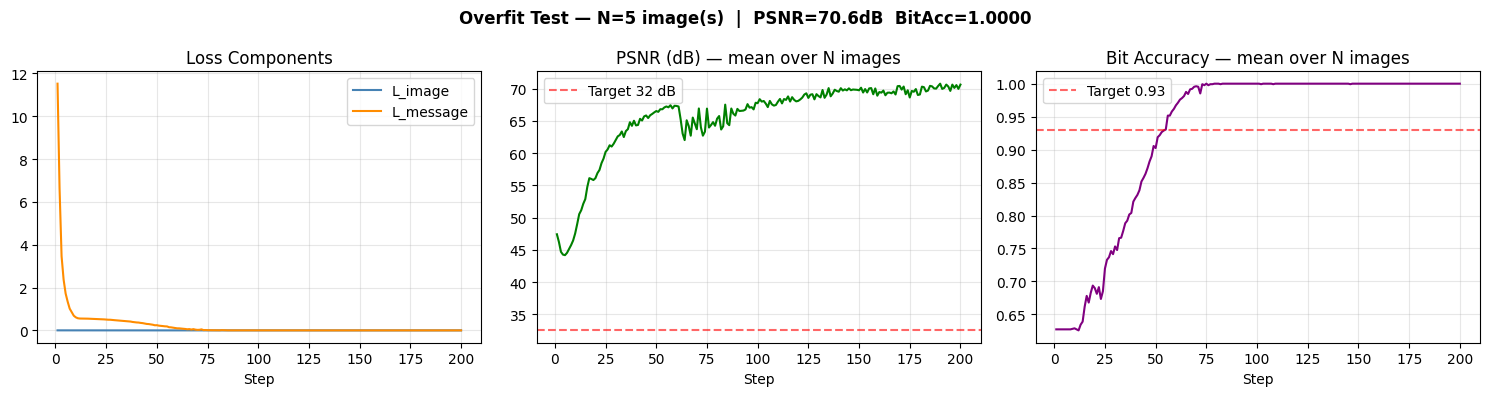

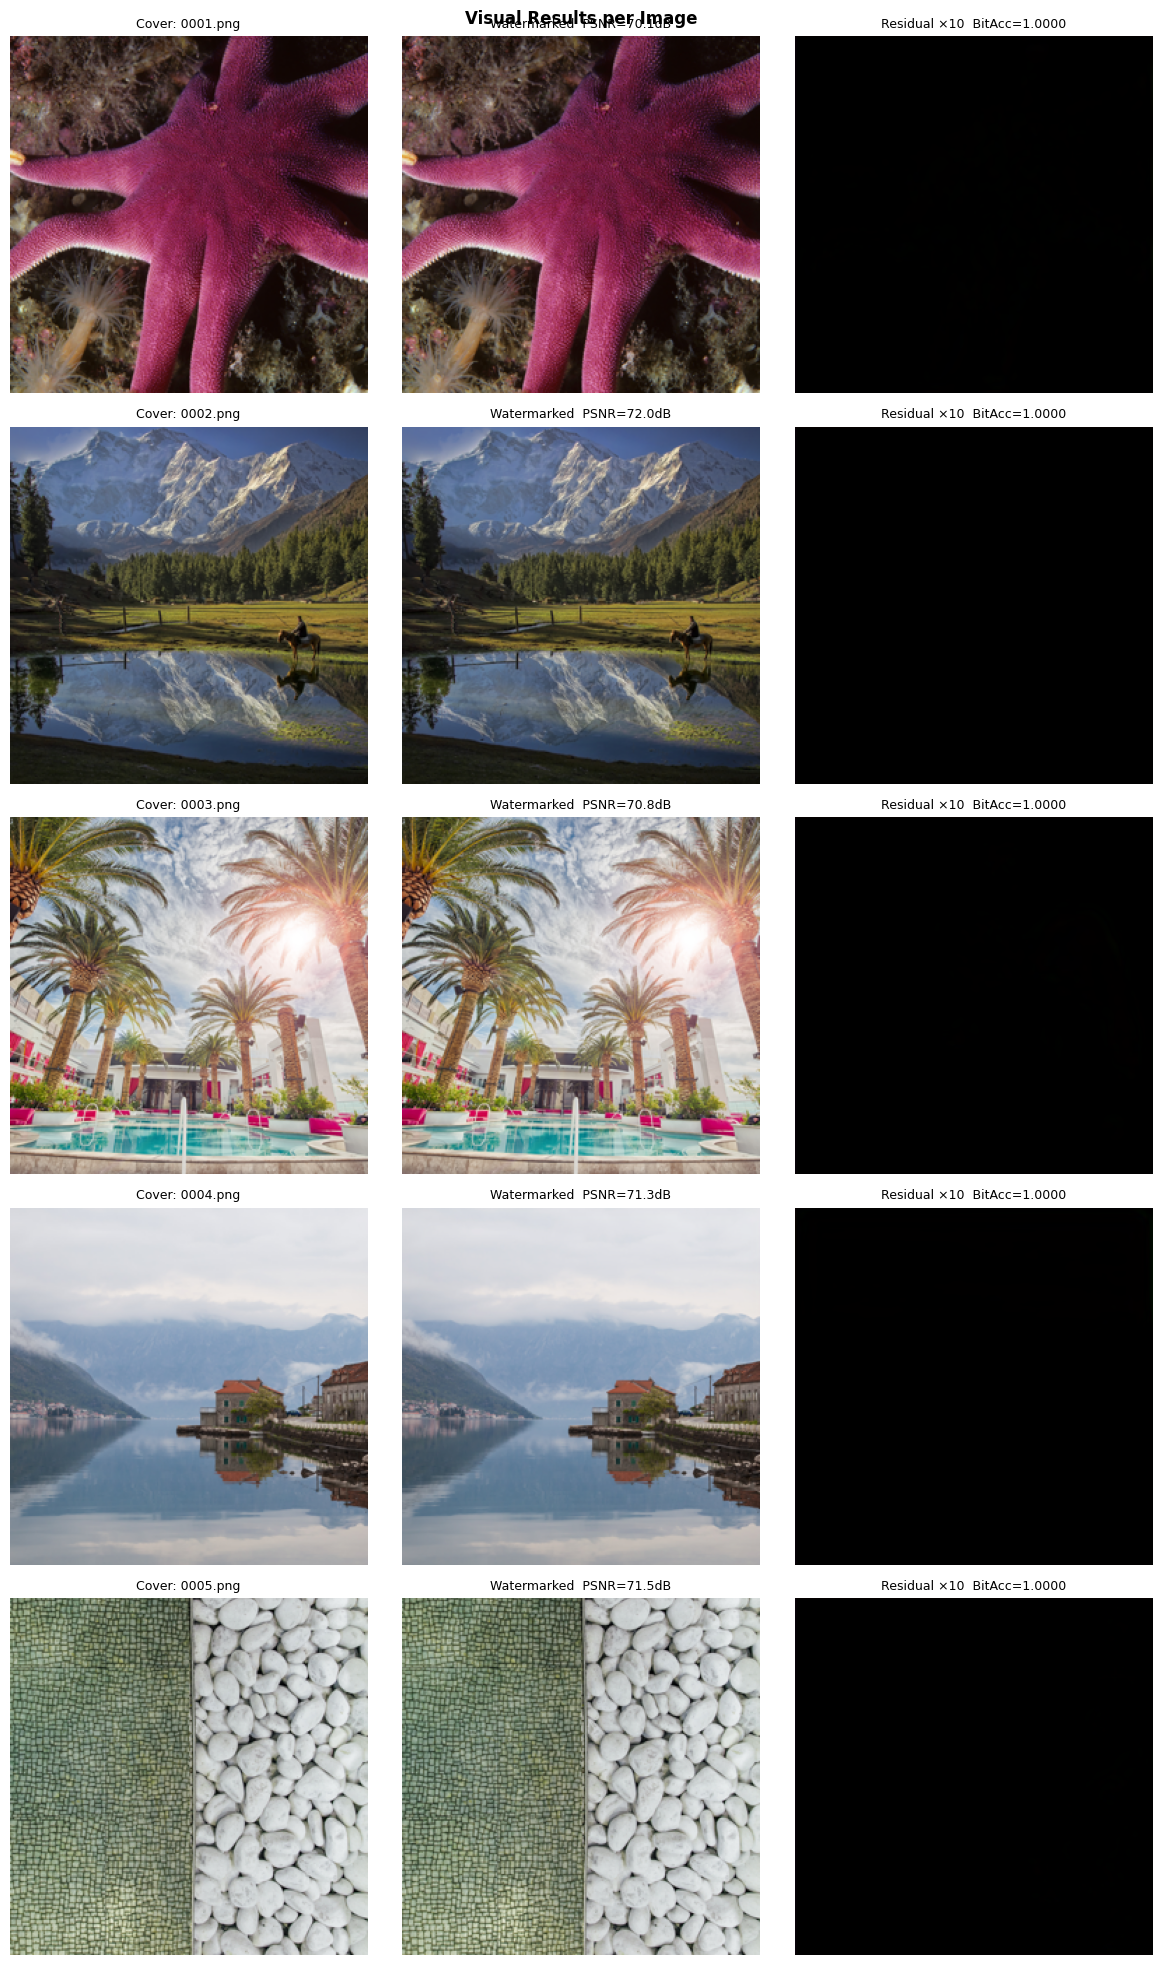

Plots saved → /content/drive/MyDrive/swin_watermark/viz


In [39]:
# =============================================================================
# SINGLE / FEW IMAGE OVERFIT TEST
#
# Purpose: Verify the model CAN learn — if it cannot overfit N images,
# something is fundamentally broken (loss, gradients, BCH, etc.)
#
# Expected behaviour if model is correct:
#   N=1  : PSNR > 35 dB and BitAcc > 0.95 within ~50 steps  (pure memorisation)
#   N=5  : PSNR > 33 dB and BitAcc > 0.90 within ~200 steps (easy generalisation)
#   N=20 : PSNR > 30 dB and BitAcc > 0.80 within ~200 steps (harder)
#
# Each image gets its OWN unique fixed watermark — the model must learn to
# embed different messages into different images simultaneously.
# =============================================================================

import matplotlib.pyplot as plt

# ── TUNABLE: change this to test with more images ─────────────────────────────
N_OVERFIT_IMAGES  = 5      # ↑ try 1, 5, 10, 20
OVERFIT_STEPS     = 200    # gradient steps total
OVERFIT_LR        = 1e-4   # learning rate for this test
OVERFIT_IMG_SIZE  = 256    # must match current MODEL img_size
LOG_EVERY         = 10     # print every N steps

# Pass thresholds scale with N — harder to perfectly overfit more images
PSNR_PASS_THRESH    = max(28.0, 35.0 - N_OVERFIT_IMAGES * 0.5)
BITACC_PASS_THRESH  = max(0.80, 0.98 - N_OVERFIT_IMAGES * 0.01)

print(f"Overfit test config:")
print(f"  N images  : {N_OVERFIT_IMAGES}")
print(f"  Steps     : {OVERFIT_STEPS}")
print(f"  LR        : {OVERFIT_LR}")
print(f"  Pass gate : PSNR > {PSNR_PASS_THRESH:.1f} dB  AND  "
      f"BitAcc > {BITACC_PASS_THRESH:.2f}")

# ── Collect image paths ───────────────────────────────────────────────────────
_all_paths = (sorted(DIV2K_TRAIN_DIR.rglob("*.png")) +
              sorted(DIV2K_TRAIN_DIR.rglob("*.jpg")))

if len(_all_paths) == 0:
    raise RuntimeError(
        f"No images found in {DIV2K_TRAIN_DIR}. "
        "Run Cell 14 to download DIV2K first."
    )

# Take first N_OVERFIT_IMAGES paths (deterministic — same images every run)
_selected_paths = _all_paths[:N_OVERFIT_IMAGES]
print(f"\nImages selected:")
for p in _selected_paths:
    print(f"  {p.name}")

# ── Build fixed dataset: N covers + N unique watermarks ───────────────────────
_transform = T.Compose([
    T.Resize(OVERFIT_IMG_SIZE + 32, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(OVERFIT_IMG_SIZE),
    T.ToTensor(),
])

_covers   = []   # list of (1, 3, H, W) tensors
_wm_batch = []   # list of (1, BCH_BITS) tensors
_msgs     = []   # list of raw 128-bit messages (for final BER check)

_rng_test = np.random.default_rng(seed=0)

for _idx, _path in enumerate(_selected_paths):
    try:
        _pil = Image.open(_path).convert("RGB")
    except Exception as e:
        print(f"  Warning: could not open {_path.name}: {e} — skipping.")
        continue

    _covers.append(_transform(_pil).unsqueeze(0).to(DEVICE))

    # Each image gets its own unique fixed watermark
    _msg = _rng_test.integers(0, 2, CFG.watermark_bits).astype(np.int32)
    _cw  = BCH_CODEC.encode(_msg)
    _wm_batch.append(torch.from_numpy(_cw).float().unsqueeze(0).to(DEVICE))
    _msgs.append(_msg)
    print(f"  [{_idx+1}] {_path.name}  wm[:8]={_msg[:8]}")

# Stack into batched tensors: (N, 3, H, W) and (N, BCH_BITS)
_cover_batch = torch.cat(_covers,   dim=0)   # (N, 3, H, W)
_wm_batch    = torch.cat(_wm_batch, dim=0)   # (N, BCH_BITS)
N_ACTUAL     = _cover_batch.shape[0]

print(f"\nCover batch  : {_cover_batch.shape}")
print(f"Watermark batch: {_wm_batch.shape}")

# ── Fresh optimizers for this test (do NOT touch main training state) ─────────
_overfit_params = (list(MODEL.encoder.parameters()) +
                   list(MODEL.decoder.parameters()))
_overfit_opt    = torch.optim.AdamW(
    _overfit_params,
    lr           = OVERFIT_LR,
    betas        = CFG.betas,
    weight_decay = 0.0,   # no regularisation — we WANT to overfit
)

# ── History ───────────────────────────────────────────────────────────────────
_history = {
    "step"    : [],
    "loss"    : [],
    "psnr"    : [],
    "bit_acc" : [],
    "l_img"   : [],
    "l_msg"   : [],
}

# ── Overfit loop ──────────────────────────────────────────────────────────────
print(f"\nRunning {OVERFIT_STEPS} steps on {N_ACTUAL} image(s)...")
print(f"{'Step':>6}  {'Loss':>8}  {'L_img':>8}  {'L_msg':>8}  "
      f"{'PSNR':>8}  {'BitAcc':>8}")
print("-" * 58)

MODEL.train()

for _step in range(1, OVERFIT_STEPS + 1):

    _overfit_opt.zero_grad(set_to_none=True)

    # Forward on all N images at once — no attack, no discriminator
    _out         = MODEL(_cover_batch, _wm_batch, apply_attack=False)
    _watermarked = _out["watermarked"]   # (N, 3, H, W)
    _logits      = _out["logits"]        # (N, BCH_BITS)

    # Loss over all N images (mean-reduced automatically)
    _l_img = CRITERION.image_loss(_cover_batch, _watermarked)
    _l_msg = CRITERION.message_loss(_logits, _wm_batch)
    _loss  = CFG.lambda_image * _l_img + CFG.lambda_message * _l_msg

    _loss.backward()
    torch.nn.utils.clip_grad_norm_(_overfit_params, CFG.grad_clip_norm)
    _overfit_opt.step()

    # ── Metrics (mean over N images) ──────────────────────────────────────────
    with torch.no_grad():
        # Per-image PSNR averaged
        _psnr_list = [
            compute_psnr(_cover_batch[i:i+1], _watermarked[i:i+1])
            for i in range(N_ACTUAL)
        ]
        _psnr    = sum(_psnr_list) / len(_psnr_list)
        _bit_acc = compute_bit_accuracy(_logits, _wm_batch)

    _history["step"].append(_step)
    _history["loss"].append(_loss.item())
    _history["psnr"].append(_psnr)
    _history["bit_acc"].append(_bit_acc)
    _history["l_img"].append(_l_img.item())
    _history["l_msg"].append(_l_msg.item())

    if _step % LOG_EVERY == 0 or _step == 1:
        print(f"{_step:>6}  {_loss.item():>8.4f}  {_l_img.item():>8.4f}  "
              f"{_l_msg.item():>8.4f}  {_psnr:>8.2f}  {_bit_acc:>8.4f}")

# ── Per-image final metrics ───────────────────────────────────────────────────
print(f"\nPer-image breakdown at step {OVERFIT_STEPS}:")
print(f"  {'Image':<20}  {'PSNR':>8}  {'BitAcc':>8}")
print(f"  {'-'*40}")
MODEL.eval()
with torch.no_grad():
    _final_out = MODEL(_cover_batch, _wm_batch, apply_attack=False)
    _final_wm  = _final_out["watermarked"]
    _final_log = _final_out["logits"]
    for i in range(N_ACTUAL):
        _p = compute_psnr(_cover_batch[i:i+1], _final_wm[i:i+1])
        _a = compute_bit_accuracy(_final_log[i:i+1], _wm_batch[i:i+1])
        _name = _selected_paths[i].name if i < len(_selected_paths) else f"img_{i}"
        print(f"  {_name:<20}  {_p:>8.2f}  {_a:>8.4f}")

# ── Final verdict ─────────────────────────────────────────────────────────────
_final_psnr    = _history["psnr"][-1]
_final_bit_acc = _history["bit_acc"][-1]
_final_loss    = _history["loss"][-1]

print("\n" + "=" * 58)
print(f"OVERFIT TEST RESULT  (N={N_ACTUAL} images)")
print("=" * 58)
print(f"  Final PSNR    : {_final_psnr:.2f} dB  "
      f"{'✓ PASS' if _final_psnr > PSNR_PASS_THRESH else '⚠ FAIL'} "
      f"(threshold: {PSNR_PASS_THRESH:.1f})")
print(f"  Final BitAcc  : {_final_bit_acc:.4f}   "
      f"{'✓ PASS' if _final_bit_acc > BITACC_PASS_THRESH else '⚠ FAIL'} "
      f"(threshold: {BITACC_PASS_THRESH:.2f})")
print(f"  Final Loss    : {_final_loss:.4f}")

_pass = _final_psnr > PSNR_PASS_THRESH and _final_bit_acc > BITACC_PASS_THRESH
if _pass:
    print(f"\n  ✓ Model is CORRECT for N={N_ACTUAL}.")
    print(f"  Proceed to full training (Cell 17).")
elif _final_psnr > PSNR_PASS_THRESH and _final_bit_acc <= BITACC_PASS_THRESH:
    print(f"\n  ⚠ Image quality OK but watermark not fully learned.")
    print(f"  Try: more steps, higher OVERFIT_LR, or lower N_OVERFIT_IMAGES.")
elif _final_psnr <= PSNR_PASS_THRESH and _final_bit_acc > BITACC_PASS_THRESH:
    print(f"\n  ⚠ Watermark learned but image quality poor (artifacts).")
    print(f"  Raise lambda_image in CFG before full training.")
else:
    print(f"\n  ✗ Model failed to overfit {N_ACTUAL} images.")
    print(f"  Try: N_OVERFIT_IMAGES=1 first, more steps, higher LR.")

# ── Plots ─────────────────────────────────────────────────────────────────────
_fig, _axes = plt.subplots(1, 3, figsize=(15, 4))
_fig.suptitle(
    f"Overfit Test — N={N_ACTUAL} image(s)  |  "
    f"PSNR={_final_psnr:.1f}dB  BitAcc={_final_bit_acc:.4f}",
    fontsize=12, fontweight="bold"
)

_axes[0].plot(_history["step"], _history["l_img"],
              label="L_image",   color="steelblue")
_axes[0].plot(_history["step"], _history["l_msg"],
              label="L_message", color="darkorange")
_axes[0].set_title("Loss Components")
_axes[0].legend(); _axes[0].grid(alpha=0.3); _axes[0].set_xlabel("Step")

_axes[1].plot(_history["step"], _history["psnr"], color="green")
_axes[1].axhline(y=PSNR_PASS_THRESH, color="red",
                 linestyle="--", alpha=0.6,
                 label=f"Target {PSNR_PASS_THRESH:.0f} dB")
_axes[1].set_title("PSNR (dB) — mean over N images")
_axes[1].legend(); _axes[1].grid(alpha=0.3); _axes[1].set_xlabel("Step")

_axes[2].plot(_history["step"], _history["bit_acc"], color="purple")
_axes[2].axhline(y=BITACC_PASS_THRESH, color="red",
                 linestyle="--", alpha=0.6,
                 label=f"Target {BITACC_PASS_THRESH:.2f}")
_axes[2].set_title("Bit Accuracy — mean over N images")
_axes[2].legend(); _axes[2].grid(alpha=0.3); _axes[2].set_xlabel("Step")

plt.tight_layout()
plt.savefig(str(VIZ_DIR / f"overfit_test_N{N_ACTUAL}.png"),
            dpi=120, bbox_inches="tight")
plt.show()

# ── Visual grid: cover | watermarked | residual for each image ────────────────
def _to_np(t):
    return t.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

_fig2, _axes2 = plt.subplots(N_ACTUAL, 3,
                              figsize=(12, 4 * N_ACTUAL),
                              squeeze=False)
_fig2.suptitle("Visual Results per Image", fontsize=12, fontweight="bold")

with torch.no_grad():
    for i in range(N_ACTUAL):
        _c   = _cover_batch[i:i+1]
        _w   = _final_wm[i:i+1]
        _res = (_w - _c).abs() * 10
        _name = (_selected_paths[i].name
                 if i < len(_selected_paths) else f"img_{i}")
        _p  = compute_psnr(_c, _w)
        _a  = compute_bit_accuracy(_final_log[i:i+1], _wm_batch[i:i+1])

        _axes2[i][0].imshow(_to_np(_c))
        _axes2[i][0].set_title(f"Cover: {_name}", fontsize=9)
        _axes2[i][0].axis("off")

        _axes2[i][1].imshow(_to_np(_w))
        _axes2[i][1].set_title(f"Watermarked  PSNR={_p:.1f}dB", fontsize=9)
        _axes2[i][1].axis("off")

        _axes2[i][2].imshow(_to_np(_res.clamp(0, 1)))
        _axes2[i][2].set_title(f"Residual ×10  BitAcc={_a:.4f}", fontsize=9)
        _axes2[i][2].axis("off")

plt.tight_layout()
plt.savefig(str(VIZ_DIR / f"overfit_visual_N{N_ACTUAL}.png"),
            dpi=120, bbox_inches="tight")
plt.show()
print(f"Plots saved → {VIZ_DIR}")

In [ ]:
# =============================================================================
# CELL 17: Phase 1 Training Loop — 256×256 resolution
#
# Full research-grade training with:
#   - AMP (mixed precision)
#   - Gradient clipping
#   - Separate optimizers for (encoder+decoder) vs discriminator
#   - LR warmup + cosine annealing
#   - Best model tracking (PSNR + bit_acc combined score)
#   - Drive overwrite checkpointing
#   - CSV logging
#   - Per-epoch visualization
# =============================================================================

def build_optimizers_and_schedulers(
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    lr_enc: float,
    lr_disc: float,
    warmup_epochs: int,
    total_epochs: int,
    cfg: WatermarkConfig,
):
    """
    Build AdamW optimizers and CosineAnnealingLR schedulers with linear warmup.

    Returns:
        opt_main  : optimizer for encoder + decoder
        opt_disc  : optimizer for discriminator
        sched_main: scheduler for opt_main
        sched_disc: scheduler for opt_disc
    """
    # ── Main optimizer (encoder + decoder parameters) ─────────────────────────
    main_params = list(model.encoder.parameters()) + \
                  list(model.decoder.parameters())
    opt_main = AdamW(main_params, lr=lr_enc,
                     betas=cfg.betas, weight_decay=cfg.weight_decay)

    # ── Discriminator optimizer ───────────────────────────────────────────────
    opt_disc = AdamW(discriminator.parameters(), lr=lr_disc,
                     betas=cfg.betas, weight_decay=cfg.weight_decay)

    # ── Schedulers: linear warmup → cosine annealing ──────────────────────────
    def make_scheduler(optimizer, warmup_ep, total_ep):
        warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0,
                          total_iters=warmup_ep)
        cosine = CosineAnnealingLR(optimizer,
                                   T_max=max(1, total_ep - warmup_ep),
                                   eta_min=1e-6)
        return SequentialLR(optimizer, schedulers=[warmup, cosine],
                            milestones=[warmup_ep])

    sched_main = make_scheduler(opt_main, warmup_epochs, total_epochs)
    sched_disc = make_scheduler(opt_disc, warmup_epochs, total_epochs)

    return opt_main, opt_disc, sched_main, sched_disc


@torch.no_grad()
def save_viz_grid(
    model: WatermarkingModel,
    val_batch: Dict[str, torch.Tensor],
    epoch: int,
    phase: int,
    out_dir: Path,
) -> None:
    """
    Save a comparison grid: [cover | watermarked | residual×10 | attacked]
    for the first 4 images in a validation batch.
    """
    model.eval()
    cover   = val_batch["image"][:4].to(DEVICE)
    wm_bits = val_batch["wm_coded"][:4].to(DEVICE)

    out        = model(cover, wm_bits, apply_attack=True)
    watermarked = out["watermarked"]
    attacked    = out["attacked"]
    residual    = (watermarked - cover).abs() * 10.0   # amplify for visibility
    residual    = residual.clamp(0.0, 1.0)

    # Stack: cover, watermarked, residual, attacked — 4 images × 4 cols
    grid = make_grid(
        torch.cat([cover, watermarked, residual, attacked], dim=0),
        nrow=4, normalize=False, pad_value=1.0
    )
    save_image(grid, out_dir / f"phase{phase}_epoch{epoch:04d}.png")


def run_validation(
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    val_loader: DataLoader,
    criterion: WatermarkLoss,
    cfg: WatermarkConfig,
) -> Dict[str, float]:
    """
    Run full validation loop and return averaged metrics.
    """
    model.eval()
    discriminator.eval()
    accum = {k: 0.0 for k in
             ["loss_total", "loss_image", "loss_message",
              "loss_adv_g", "psnr", "ssim", "ber", "bit_acc"]}
    n_batches = 0

    for batch in val_loader:
        metrics = evaluate_batch(model, batch, criterion, cfg)
        for k in accum:
            accum[k] += metrics.get(k, 0.0)
        n_batches += 1

    return {k: v / max(1, n_batches) for k, v in accum.items()}


def train_phase(
    phase: int,
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    criterion: WatermarkLoss,
    cfg: WatermarkConfig,
    img_size: int,
    batch_size: int,
    lr_enc: float,
    lr_disc: float,
    warmup_epochs: int,
    total_epochs: int,
    best_ckpt_path: Path,
    last_ckpt_path: Path,
    log_csv_path: Path,
    resume: bool = True,
) -> None:
    """
    Generic training loop used for both Phase 1 and Phase 2.

    Args:
        phase          : 1 or 2 (for logging / checkpoint labeling)
        model          : WatermarkingModel
        discriminator  : PatchDiscriminator
        criterion      : WatermarkLoss
        cfg            : WatermarkConfig
        img_size       : training resolution
        batch_size     : batch size
        lr_enc         : initial LR for encoder+decoder
        lr_disc        : initial LR for discriminator
        warmup_epochs  : LR warmup epochs
        total_epochs   : total training epochs
        best_ckpt_path : path to save best model (overwrite)
        last_ckpt_path : path to save last epoch checkpoint (overwrite)
        log_csv_path   : path to CSV training log
        resume         : if True, try to resume from last_ckpt_path
    """
    # ── Build DataLoaders ──────────────────────────────────────────────────────
    train_loader, val_loader = build_dataloaders(cfg, img_size, batch_size)

    # ── Build optimizers and schedulers ───────────────────────────────────────
    opt_main, opt_disc, sched_main, sched_disc = build_optimizers_and_schedulers(
        model, discriminator,
        lr_enc, lr_disc, warmup_epochs, total_epochs, cfg
    )

    # ── AMP scaler ────────────────────────────────────────────────────────────
    scaler = GradScaler(enabled=cfg.use_amp)

    # ── Resume from checkpoint if requested ───────────────────────────────────
    start_epoch  = 0
    best_score   = -float("inf")   # score = PSNR + 10*bit_acc (composite)
    if resume:
        start_epoch, _, prev_metrics = load_checkpoint(
            last_ckpt_path, model, discriminator,
            opt_main, opt_disc, sched_main, sched_disc, scaler
        )
        if prev_metrics:
            best_score = (prev_metrics.get("psnr", 0) +
                          10 * prev_metrics.get("bit_acc", 0))

    # ── Initialize CSV log ────────────────────────────────────────────────────
    init_csv_log(log_csv_path, LOG_FIELDS)

    # Grab one fixed val batch for visualization (reuse same batch each epoch)
    _viz_batch = next(iter(val_loader))

    logger.info(f"{'='*60}")
    logger.info(f"Starting Phase {phase} training | "
                f"res={img_size}×{img_size} | "
                f"epochs={total_epochs} | bs={batch_size}")
    logger.info(f"{'='*60}")

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, total_epochs):
        model.train()
        discriminator.train()
        epoch_start = time.time()

        # Running accumulators for epoch-level logging
        epoch_metrics = {k: 0.0 for k in
                         ["loss_total", "loss_image", "loss_message",
                          "loss_adv_g", "loss_disc", "psnr", "ssim",
                          "ber", "bit_acc"]}
        n_steps = 0

        for step, batch in enumerate(train_loader):
            cover   = batch["image"].to(DEVICE, non_blocking=True)
            wm_bits = batch["wm_coded"].to(DEVICE, non_blocking=True)

            # ── (A) Train Discriminator ────────────────────────────────────────
            opt_disc.zero_grad(set_to_none=True)

            with autocast(enabled=cfg.use_amp):
                # Get watermarked image (no gradient through encoder here)
                with torch.no_grad():
                    out        = model(cover, wm_bits, apply_attack=False)
                    watermarked= out["watermarked"]

                disc_real = discriminator(cover)
                disc_fake = discriminator(watermarked.detach())
                loss_disc = criterion.discriminator_loss(disc_real, disc_fake)

            scaler.scale(loss_disc).backward()
            scaler.unscale_(opt_disc)
            nn.utils.clip_grad_norm_(discriminator.parameters(),
                                     cfg.grad_clip_norm)
            scaler.step(opt_disc)
            scaler.update()

            # ── (B) Train Encoder + Decoder ────────────────────────────────────
            opt_main.zero_grad(set_to_none=True)

            with autocast(enabled=cfg.use_amp):
                # Full forward pass WITH attack
                out         = model(cover, wm_bits, apply_attack=True)
                watermarked = out["watermarked"]
                logits      = out["logits"]

                # Discriminator on watermarked (not detached — grad flows to encoder)
                disc_on_wm  = discriminator(watermarked)

                total_loss, breakdown = criterion.total_generator_loss(
                    cover, watermarked, logits, wm_bits, disc_on_wm
                )

            scaler.scale(total_loss).backward()
            scaler.unscale_(opt_main)
            nn.utils.clip_grad_norm_(
                list(model.encoder.parameters()) +
                list(model.decoder.parameters()),
                cfg.grad_clip_norm
            )
            scaler.step(opt_main)
            scaler.update()

            # ── Accumulate step metrics ────────────────────────────────────────
            with torch.no_grad():
                step_psnr    = compute_psnr(cover, watermarked)
                step_ssim    = compute_ssim(cover, watermarked)
                step_ber     = compute_ber(logits, wm_bits)
                step_bit_acc = 1.0 - step_ber

            epoch_metrics["loss_total"]   += breakdown["loss_total"]
            epoch_metrics["loss_image"]   += breakdown["loss_image"]
            epoch_metrics["loss_message"] += breakdown["loss_message"]
            epoch_metrics["loss_adv_g"]   += breakdown["loss_adv_g"]
            epoch_metrics["loss_disc"]    += loss_disc.item()
            epoch_metrics["psnr"]         += step_psnr
            epoch_metrics["ssim"]         += step_ssim
            epoch_metrics["ber"]          += step_ber
            epoch_metrics["bit_acc"]      += step_bit_acc
            n_steps += 1

            # ── Step-level log ─────────────────────────────────────────────────
            if (step + 1) % cfg.log_every_n_steps == 0:
                logger.info(
                    f"P{phase} E[{epoch+1:03d}/{total_epochs}] "
                    f"S[{step+1:04d}/{len(train_loader)}] | "
                    f"L={breakdown['loss_total']:.4f} "
                    f"L_img={breakdown['loss_image']:.4f} "
                    f"L_msg={breakdown['loss_message']:.4f} "
                    f"L_adv={breakdown['loss_adv_g']:.4f} "
                    f"L_disc={loss_disc.item():.4f} | "
                    f"PSNR={step_psnr:.2f}dB "
                    f"SSIM={step_ssim:.4f} "
                    f"BER={step_ber:.4f} "
                    f"Acc={step_bit_acc:.4f} | "
                    f"Atk={out['attack_name']}"
                )

        # ── End of epoch: average metrics ─────────────────────────────────────
        train_avg = {k: v / max(1, n_steps) for k, v in epoch_metrics.items()}

        # ── Validation pass ───────────────────────────────────────────────────
        val_avg = run_validation(model, discriminator, val_loader,
                                 criterion, cfg)

        epoch_time = time.time() - epoch_start
        lr_main_now = opt_main.param_groups[0]["lr"]
        lr_disc_now = opt_disc.param_groups[0]["lr"]

        logger.info(
            f"\n{'─'*60}\n"
            f"Phase {phase} Epoch {epoch+1}/{total_epochs} Summary\n"
            f"  TRAIN: PSNR={train_avg['psnr']:.2f}dB  "
            f"SSIM={train_avg['ssim']:.4f}  "
            f"BER={train_avg['ber']:.4f}  "
            f"Acc={train_avg['bit_acc']:.4f}\n"
            f"  VAL  : PSNR={val_avg['psnr']:.2f}dB  "
            f"SSIM={val_avg['ssim']:.4f}  "
            f"BER={val_avg['ber']:.4f}  "
            f"Acc={val_avg['bit_acc']:.4f}\n"
            f"  LR main={lr_main_now:.2e}  LR disc={lr_disc_now:.2e}  "
            f"Time={epoch_time:.1f}s\n"
            f"{'─'*60}"
        )

        # ── CSV log ───────────────────────────────────────────────────────────
        for split, avg in [("train", train_avg), ("val", val_avg)]:
            row = {
                "epoch"        : epoch + 1,
                "phase"        : phase,
                "split"        : split,
                "loss_total"   : avg.get("loss_total", 0),
                "loss_image"   : avg.get("loss_image", 0),
                "loss_message" : avg.get("loss_message", 0),
                "loss_adv_g"   : avg.get("loss_adv_g", 0),
                "loss_disc"    : avg.get("loss_disc", 0),
                "psnr"         : avg.get("psnr", 0),
                "ssim"         : avg.get("ssim", 0),
                "ber"          : avg.get("ber", 0),
                "bit_acc"      : avg.get("bit_acc", 0),
                "lr_main"      : lr_main_now,
                "lr_disc"      : lr_disc_now,
                "epoch_time_s" : epoch_time if split == "train" else 0,
            }
            append_csv_log(log_csv_path, row)

        # ── LR scheduler step ────────────────────────────────────────────────
        sched_main.step()
        sched_disc.step()

        # ── Save last checkpoint (always overwrite) ───────────────────────────
        save_checkpoint(
            last_ckpt_path, model, discriminator,
            opt_main, opt_disc, sched_main, sched_disc,
            epoch + 1, val_avg, phase, scaler
        )

        # ── Save best checkpoint (overwrite only if improved) ─────────────────
        # Composite score: balance PSNR (image quality) and bit accuracy
        current_score = val_avg["psnr"] + 10.0 * val_avg["bit_acc"]
        if current_score > best_score:
            best_score = current_score
            save_checkpoint(
                best_ckpt_path, model, discriminator,
                opt_main, opt_disc, sched_main, sched_disc,
                epoch + 1, val_avg, phase, scaler
            )
            logger.info(f"  ★ New best model saved! Score={best_score:.4f} "
                        f"(PSNR={val_avg['psnr']:.2f}, "
                        f"Acc={val_avg['bit_acc']:.4f})")

        # ── Visualization grid ────────────────────────────────────────────────
        if (epoch + 1) % cfg.save_viz_every_n_epochs == 0:
            save_viz_grid(model, _viz_batch, epoch + 1, phase, VIZ_DIR)
            logger.info(f"  Visualization saved → {VIZ_DIR}")

    logger.info(f"Phase {phase} training complete. Best score: {best_score:.4f}")


# ── Run Phase 1 ───────────────────────────────────────────────────────────────
print("Starting Phase 1 training (256×256)...")
print(f"  Epochs     : {CFG.phase1_epochs}")
print(f"  Batch size : {CFG.phase1_batch_size}")
print(f"  LR (enc)   : {CFG.phase1_lr_enc}")
print(f"  LR (disc)  : {CFG.phase1_lr_disc}")
print()

train_phase(
    phase          = 1,
    model          = MODEL,
    discriminator  = DISC,
    criterion      = CRITERION,
    cfg            = CFG,
    img_size       = CFG.img_size_phase1,
    batch_size     = CFG.phase1_batch_size,
    lr_enc         = CFG.phase1_lr_enc,
    lr_disc        = CFG.phase1_lr_disc,
    warmup_epochs  = CFG.phase1_warmup_epochs,
    total_epochs   = CFG.phase1_epochs,
    best_ckpt_path = CKPT_PHASE1,
    last_ckpt_path = CKPT_LAST,
    log_csv_path   = LOG_CSV_P1,
    resume         = True,     # set False to restart Phase 1 from scratch
)

Starting Phase 1 training (256×256)...
  Epochs     : 100
  Batch size : 16
  LR (enc)   : 5e-05
  LR (disc)  : 2e-05



In [ ]:
# =============================================================================
# CELL 18: Phase 2 Fine-tuning — 512×512 resolution
#
# Loads the best Phase 1 checkpoint and fine-tunes at full 512×512.
# Lower LR, smaller batch, same training infrastructure as Phase 1.
# =============================================================================

print("Loading best Phase 1 checkpoint for Phase 2 fine-tuning...")

# Load best Phase 1 model weights into MODEL before starting Phase 2.
# We reload only model/disc weights (not optimizer state) so Phase 2 starts
# with a fresh optimizer at the new lower LR.
if CKPT_PHASE1.exists():
    _state = torch.load(CKPT_PHASE1, map_location=DEVICE)
    MODEL.load_state_dict(_state["model_state"])
    DISC.load_state_dict(_state["disc_state"])
    logger.info(f"Loaded Phase 1 best: epoch={_state['epoch']}, "
                f"metrics={_state['metrics']}")
else:
    logger.warning("Phase 1 checkpoint not found. Starting Phase 2 from scratch.")

print("\nStarting Phase 2 fine-tuning (512×512)...")
print(f"  Epochs     : {CFG.phase2_epochs}")
print(f"  Batch size : {CFG.phase2_batch_size}")
print(f"  LR (enc)   : {CFG.phase2_lr_enc}")
print(f"  LR (disc)  : {CFG.phase2_lr_disc}")
print()

train_phase(
    phase          = 2,
    model          = MODEL,
    discriminator  = DISC,
    criterion      = CRITERION,
    cfg            = CFG,
    img_size       = CFG.img_size_phase2,
    batch_size     = CFG.phase2_batch_size,
    lr_enc         = CFG.phase2_lr_enc,
    lr_disc        = CFG.phase2_lr_disc,
    warmup_epochs  = CFG.phase2_warmup_epochs,
    total_epochs   = CFG.phase2_epochs,
    best_ckpt_path = CKPT_PHASE2,
    last_ckpt_path = CKPT_LAST,
    log_csv_path   = LOG_CSV_P2,
    resume         = False,    # start Phase 2 fresh (new optimizer state)
)

In [ ]:
# =============================================================================
# CELL 19: Full evaluation on custom test set + per-attack breakdown + plots.
#
# Loads best Phase 2 checkpoint (or Phase 1 if Phase 2 not available).
# Runs each attack individually and reports PSNR, SSIM, BER, Accuracy.
# =============================================================================

@torch.no_grad()
def full_evaluation(
    model: WatermarkingModel,
    discriminator: PatchDiscriminator,
    criterion: WatermarkLoss,
    cfg: WatermarkConfig,
    eval_dirs: List[Path],
    img_size: int,
) -> Dict[str, Dict[str, float]]:
    """
    Evaluate the model against every attack individually.

    Returns:
        results : dict keyed by attack name → dict of averaged metrics
    """
    model.eval()
    discriminator.eval()

    eval_dataset = ImageFolderDataset(
        root_dirs=eval_dirs,
        img_size=img_size,
        split="eval",
        cfg=cfg,
    )
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=max(1, cfg.phase2_batch_size),
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )

    attack_names = list(cfg.attack_probs.keys())
    results: Dict[str, Dict[str, float]] = {}

    for atk_name in attack_names:
        accum  = {"psnr": 0., "ssim": 0., "ber": 0., "bit_acc": 0.}
        n_batches = 0

        for batch in eval_loader:
            m = evaluate_batch(model, batch, criterion, cfg,
                               attack_name=atk_name)
            for k in accum:
                accum[k] += m[k]
            n_batches += 1

        results[atk_name] = {k: v / max(1, n_batches)
                              for k, v in accum.items()}

    return results


def plot_evaluation_results(
    results: Dict[str, Dict[str, float]],
    phase: int,
) -> None:
    """
    Plot PSNR, SSIM, BER, and Bit Accuracy bar charts across all attacks.
    Saves to VIZ_DIR and shows inline.
    """
    attacks  = list(results.keys())
    psnr_vals= [results[a]["psnr"]    for a in attacks]
    ssim_vals= [results[a]["ssim"]    for a in attacks]
    ber_vals = [results[a]["ber"]     for a in attacks]
    acc_vals = [results[a]["bit_acc"] for a in attacks]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f"Phase {phase} Evaluation — Per-Attack Breakdown\n"
        f"(128-bit watermark, BCH({CFG.bch_t}) error correction)",
        fontsize=14, fontweight="bold"
    )

    colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(attacks)))

    for ax, vals, title, ylabel, better in zip(
        axes.flat,
        [psnr_vals, ssim_vals, ber_vals, acc_vals],
        ["PSNR (dB)", "SSIM", "Bit Error Rate", "Bit Accuracy"],
        ["dB", "", "", ""],
        ["↑ higher better", "↑ higher better",
         "↓ lower better", "↑ higher better"],
    ):
        bars = ax.bar(attacks, vals, color=colors, edgecolor="white",
                      linewidth=0.8)
        ax.set_title(f"{title}   {better}", fontsize=11)
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(attacks)))
        ax.set_xticklabels(attacks, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        # Annotate bars
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    out_path = VIZ_DIR / f"phase{phase}_eval_results.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Evaluation plot saved → {out_path}")


def plot_training_curves(log_csv: Path, phase: int) -> None:
    """Plot loss and metric curves from the CSV training log."""
    if not log_csv.exists():
        print(f"No log found at {log_csv}")
        return

    import pandas as pd
    df     = pd.read_csv(log_csv)
    train  = df[df["split"] == "train"]
    val    = df[df["split"] == "val"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Phase {phase} Training Curves", fontsize=14,
                 fontweight="bold")

    plot_pairs = [
        ("loss_total"  , "Total Loss"        ),
        ("loss_image"  , "Image Loss"        ),
        ("loss_message", "Message Loss"      ),
        ("psnr"        , "PSNR (dB)"         ),
        ("ssim"        , "SSIM"              ),
        ("bit_acc"     , "Bit Accuracy"      ),
    ]
    for ax, (col, label) in zip(axes.flat, plot_pairs):
        ax.plot(train["epoch"], train[col], label="train", linewidth=1.5)
        ax.plot(val["epoch"],   val[col],   label="val",   linewidth=1.5,
                linestyle="--")
        ax.set_title(label); ax.set_xlabel("Epoch")
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    out_path = VIZ_DIR / f"phase{phase}_training_curves.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved → {out_path}")


# ── Load best available checkpoint ────────────────────────────────────────────
best_ckpt = CKPT_PHASE2 if CKPT_PHASE2.exists() else CKPT_PHASE1
if best_ckpt.exists():
    _state = torch.load(best_ckpt, map_location=DEVICE)
    MODEL.load_state_dict(_state["model_state"])
    _eval_phase = _state["phase"]
    print(f"Loaded {best_ckpt.name} (phase={_eval_phase}, "
          f"epoch={_state['epoch']})")
else:
    _eval_phase = 1
    print("No checkpoint found. Evaluating with current model weights.")

_eval_img_size = (CFG.img_size_phase2 if _eval_phase == 2
                  else CFG.img_size_phase1)

# Use custom eval dir if it has images, else fall back to val split of training data
_eval_dirs = ([CUSTOM_DIR]
              if CUSTOM_DIR.exists() and any(CUSTOM_DIR.iterdir())
              else [DIV2K_DIR, FLICKR2K_DIR])

print(f"\nRunning evaluation at {_eval_img_size}×{_eval_img_size}...")
eval_results = full_evaluation(
    MODEL, DISC, CRITERION, CFG, _eval_dirs, _eval_img_size
)

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'Attack':<18} {'PSNR (dB)':>10} {'SSIM':>8} {'BER':>8} {'Acc':>8}")
print(f"{'─'*70}")
for atk, m in eval_results.items():
    print(f"{atk:<18} {m['psnr']:>10.3f} {m['ssim']:>8.4f} "
          f"{m['ber']:>8.4f} {m['bit_acc']:>8.4f}")
print(f"{'─'*70}")

# ── Plot results ──────────────────────────────────────────────────────────────
plot_evaluation_results(eval_results, _eval_phase)

# ── Plot training curves ──────────────────────────────────────────────────────
for _phase_log, _log_path in [(1, LOG_CSV_P1), (2, LOG_CSV_P2)]:
    if _log_path.exists():
        plot_training_curves(_log_path, _phase_log)

In [35]:
# =============================================================================
# CELL 20: Inference utility
#
# Provides:
#   embed_watermark()  — embed a custom 128-bit message into any image
#   extract_watermark()— extract and BCH-decode watermark from any image
#   demo_inference()   — visual demo with side-by-side comparison
# =============================================================================

@torch.no_grad()
def embed_watermark(
    model: WatermarkingModel,
    image_path: str,
    message_bits: np.ndarray,
    img_size: int = 512,
    output_path: Optional[str] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Embed a 128-bit message into an image using the trained encoder.

    Args:
        model        : trained WatermarkingModel
        image_path   : path to input cover image
        message_bits : np.ndarray shape (128,), values in {0, 1}
        img_size     : resize image to this before embedding
        output_path  : if provided, save watermarked image here

    Returns:
        watermarked_np : np.ndarray (H, W, 3) uint8 — watermarked image
        codeword       : np.ndarray (BCH_BITS,) — BCH codeword embedded
    """
    assert len(message_bits) == CFG.watermark_bits, \
        f"message_bits must have length {CFG.watermark_bits}"

    model.eval()

    # Load and preprocess image
    img    = Image.open(image_path).convert("RGB")
    img    = img.resize((img_size, img_size), Image.BICUBIC)
    tensor = T.ToTensor()(img).unsqueeze(0).to(DEVICE)   # (1,3,H,W)

    # BCH encode the message
    codeword    = BCH_CODEC.encode(message_bits.astype(np.int32))
    wm_tensor   = torch.from_numpy(codeword).float().unsqueeze(0).to(DEVICE)

    # Forward through encoder only (no attack, no decoder)
    watermarked = model.encoder(tensor, wm_tensor)        # (1,3,H,W)
    watermarked = watermarked.squeeze(0).cpu()

    # Convert to uint8 numpy
    watermarked_np = (watermarked.permute(1,2,0).numpy() * 255).clip(0, 255).astype(np.uint8)

    if output_path:
        Image.fromarray(watermarked_np).save(output_path)
        print(f"Watermarked image saved → {output_path}")

    return watermarked_np, codeword


@torch.no_grad()
def extract_watermark(
    model: WatermarkingModel,
    image: np.ndarray,
    img_size: int = 512,
    use_bch: bool = True,
) -> Tuple[Optional[np.ndarray], np.ndarray, float]:
    """
    Extract and BCH-decode the watermark from an (attacked) watermarked image.

    Args:
        model    : trained WatermarkingModel
        image    : np.ndarray (H, W, 3) uint8
        img_size : resize image to this before extraction
        use_bch  : if True, apply BCH error correction

    Returns:
        message_bits : np.ndarray (128,) or None if BCH fails
        raw_bits     : np.ndarray (BCH_BITS,) — extracted bits before BCH
        confidence   : float — mean soft probability (higher = more confident)
    """
    model.eval()

    img    = Image.fromarray(image).resize((img_size, img_size), Image.BICUBIC)
    tensor = T.ToTensor()(img).unsqueeze(0).to(DEVICE)

    logits = model.decoder(tensor)                         # (1, BCH_BITS)
    probs  = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    raw_bits = (probs > 0.5).astype(np.int32)
    confidence = float(np.abs(probs - 0.5).mean() + 0.5)  # in [0.5, 1.0]

    if use_bch:
        message_bits = BCH_CODEC.decode(raw_bits)
    else:
        message_bits = raw_bits[:CFG.watermark_bits]

    return message_bits, raw_bits, confidence


def demo_inference(
    model: WatermarkingModel,
    image_path: str,
    img_size: int = 256,
) -> None:
    """
    End-to-end demo: embed → attack → extract → compare.
    Displays a visual comparison panel inline.
    """
    # Generate a random 128-bit message
    message = np.random.randint(0, 2, CFG.watermark_bits)
    print(f"Original message (first 16 bits): {message[:16]}")

    # Embed
    wm_img, codeword = embed_watermark(
        model, image_path, message, img_size=img_size
    )

    # Simulate JPEG attack
    atk_layer = AttackLayer(CFG)
    wm_tensor = T.ToTensor()(Image.fromarray(wm_img)).unsqueeze(0)
    atk_img_t, atk_name = atk_layer(wm_tensor, attack_name="jpeg")
    atk_img   = (atk_img_t.squeeze(0).permute(1,2,0).numpy() * 255
                 ).clip(0,255).astype(np.uint8)
    print(f"Applied attack: {atk_name}")

    # Extract from attacked image
    recovered_msg, raw_bits, conf = extract_watermark(model, atk_img, img_size)

    if recovered_msg is not None:
        ber = (recovered_msg != message).mean()
        print(f"Recovered message (first 16 bits): {recovered_msg[:16]}")
        print(f"BER after BCH decoding : {ber:.4f}")
        print(f"Bit accuracy           : {1-ber:.4f}")
    else:
        print("BCH decoding FAILED (too many bit errors)")
    print(f"Decoder confidence     : {conf:.4f}")

    # ── Visual panel ──────────────────────────────────────────────────────────
    cover   = np.array(Image.open(image_path).convert("RGB")
                       .resize((img_size, img_size)))
    residual= np.clip((wm_img.astype(int) - cover.astype(int)) * 10 + 128,
                      0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    titles    = ["Cover Image", f"Watermarked\n(strength={CFG.embedding_strength})",
                 "Residual ×10", f"After Attack\n({atk_name})"]
    images    = [cover, wm_img, residual, atk_img]

    for ax, img_np, title in zip(axes, images, titles):
        ax.imshow(img_np); ax.set_title(title, fontsize=10)
        ax.axis("off")

    psnr_val = compute_psnr(
        T.ToTensor()(Image.fromarray(cover)).unsqueeze(0),
        T.ToTensor()(Image.fromarray(wm_img)).unsqueeze(0),
    )
    ssim_val = compute_ssim(
        T.ToTensor()(Image.fromarray(cover)).unsqueeze(0),
        T.ToTensor()(Image.fromarray(wm_img)).unsqueeze(0),
    )
    fig.suptitle(
        f"Inference Demo | PSNR={psnr_val:.2f}dB | SSIM={ssim_val:.4f} | "
        f"BCH BER={ber if recovered_msg is not None else 'FAIL':.4f}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    out_path = VIZ_DIR / "demo_inference.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Demo saved → {out_path}")


# ── Example usage (uncomment and provide an image path) ───────────────────────
# demo_inference(MODEL, image_path="/content/test.jpg", img_size=256)

print("Inference utilities ready.")
print("Usage:")
print("  wm_img, codeword = embed_watermark(MODEL, 'img.jpg', message_bits)")
print("  msg, raw, conf   = extract_watermark(MODEL, wm_img_array)")
print("  demo_inference(MODEL, 'img.jpg')")

Inference utilities ready.
Usage:
  wm_img, codeword = embed_watermark(MODEL, 'img.jpg', message_bits)
  msg, raw, conf   = extract_watermark(MODEL, wm_img_array)
  demo_inference(MODEL, 'img.jpg')
